### Portifolios

FILTRO DE LIQUIDEZ

In [1]:
import pandas as pd
import re
import numpy as np

# Carregar base
df = pd.read_excel("base brasil ações.xlsx", sheet_name="PETR4", skiprows=3)

# Padronizar as datas
df.rename(columns={df.columns[0]: "Date"}, inplace=True)
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Remover colunas totalmente vazias
df = df.dropna(axis=1, how="all")

# Converter preços para numérico (manter Date como datetime)
for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Filtrar a partir de 2000
df = df[df["Date"] >= "2000-01-01"].reset_index(drop=True)

# Padronizar nomes das colunas: extrair apenas o ticker
def extrair_ticker(nome):
    if nome == "Date":
        return nome
    match = re.search(r"([A-Z0-9]{4}\d+[A-Z]?)$", str(nome))
    return match.group(1) if match else nome

df.columns = [extrair_ticker(col) for col in df.columns]

# -------------------------------
# 🔹 FILTROS DE LIQUIDEZ
# -------------------------------

# 1. Manter apenas ações com pelo menos 80% dos pregões válidos
valid_days = df.drop(columns="Date").notna().mean(axis=0)   # proporção por ação
liquid_cols = valid_days[valid_days >= 0.8].index

# 2. Remover ações cujo preço médio < 1 real
mean_prices = df[liquid_cols].mean(axis=0, skipna=True)
liquid_cols = mean_prices[mean_prices >= 1].index

# Aplicar os filtros (sempre mantendo Date)
df = df[["Date"] + list(liquid_cols)]

def tickerfilter(df):
    colunas = df.columns.tolist()
    colunas_acao = [col for col in colunas if col != "Date"]

    # Extrair a raiz do ticker (4 primeiras letras)
    ticker_roots = {}
    for col in colunas_acao:
        root = col[:4]  # Primeiras 4 letras
        if root not in ticker_roots:
            ticker_roots[root] = []
        ticker_roots[root].append(col)

    colunas_finais = ["Date"]

    for root, tickers in ticker_roots.items():
        if len(tickers) > 1:
            ticker_4 = None
            outros_tickers = []
            for ticker in tickers:
                if ticker.endswith('4'):
                    ticker_4 = ticker
                else:
                    outros_tickers.append(ticker)
            if ticker_4:
                colunas_finais.append(ticker_4)
            else:
                colunas_finais.extend(tickers)
        else:
            # Apenas um ticker dessa raiz, manter normalmente
            colunas_finais.extend(tickers)

    return df[colunas_finais]

df = tickerfilter(df)
df

,Date,ALPA4,BAZA3,ABEV3,BOBR4,BBDC4,BRAP4,BBAS3,BRKM5,CLSC4,...,SAPR4,CSNA3,TASA4,TELB4,VIVT3,TIMS3,UNIP6,USIM3,USIM5,VALE3
0,2000-01-03,0.118463,5.479419,0.230426,12.009797,0.504317,NaN,0.262556,2.957378,4.137943,...,NaN,0.288748,0.771115,2.803017,0.973145,1.947233,0.299917,NaN,0.888604,0.890991
1,2000-01-04,0.113079,5.365265,NaN,11.748715,0.468728,NaN,0.250069,2.782151,3.805005,...,NaN,0.292704,0.742016,2.803017,0.932192,1.849872,0.283122,NaN,0.872869,0.869777
2,2000-01-05,0.112002,NaN,0.222293,12.183853,0.497212,NaN,0.252630,2.957378,3.852568,...,NaN,0.308526,0.742016,2.803017,0.957332,1.830399,0.285521,NaN,0.937663,0.869777
3,2000-01-06,0.109848,5.479419,0.219853,12.009797,0.501178,NaN,0.256152,2.885247,3.662318,...,NaN,0.322370,0.727467,2.803017,0.959765,1.757378,0.278323,0.568944,1.012639,0.869777
4,2000-01-07,0.108771,5.707728,NaN,12.531962,0.501178,NaN,0.250389,2.782203,3.709880,...,NaN,0.320392,0.742016,2.803017,0.977200,1.806059,0.280722,0.578427,1.063548,0.901598
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6698,2025-09-04,10.090000,77.280000,12.160000,1.310000,16.830000,16.49,20.420000,9.140000,102.960000,...,6.99,7.650000,4.800000,11.050000,33.590000,22.650000,68.230000,4.470000,4.410000,55.710000
6699,2025-09-05,10.450000,78.210000,12.250000,1.320000,17.240000,16.60,21.150000,9.400000,102.500000,...,7.07,7.790000,4.860000,9.790000,34.000000,22.950000,67.510000,4.600000,4.520000,56.220000
6700,2025-09-08,10.280000,76.510000,12.140000,1.290000,17.150000,16.76,20.950000,9.610000,100.000000,...,6.95,7.840000,5.030000,10.000000,33.590000,22.780000,67.790000,4.680000,4.600000,56.360000
6701,2025-09-09,10.250000,79.000000,12.330000,1.310000,16.990000,16.68,21.400000,9.210000,99.490000,...,7.07,7.790000,5.130000,9.800000,33.430000,22.660000,68.500000,4.570000,4.510000,56.190000


PORTFÓLIO VALUE

In [2]:
import pandas as pd
import numpy as np

df_bm = pd.read_csv("Economatica-Market-Book 2000-2025.csv")
df_bm['Ticker'] = df_bm['Ativo'].str.split('<').str[0]
df_bm['PB'] = pd.to_numeric(df_bm['P/VPA|Em moeda orig|consolid:sim*'], errors='coerce')
df_bm['BM'] = 1 / df_bm['PB'].where(df_bm['PB'] > 0)

def quarter_to_date(q):
    qtr, year = q[:-4], q[-4:]
    month_map = {'1T': 3, '2T': 6, '3T': 9, '4T': 12}
    month = month_map.get(qtr, None)
    if month:
        return pd.to_datetime(f"{year}-{month}-01") + pd.offsets.MonthEnd(0)
    return pd.NaT

df_bm['Date'] = df_bm['Data'].apply(quarter_to_date)
df_bm = df_bm.dropna(subset=['Date'])
bm_pivot = df_bm.pivot(index='Date', columns='Ticker', values='BM')

# BM trimestral -> mensal
bm_monthly = bm_pivot.resample('ME').ffill()

# === 2. Dados de Market Cap ===
df_mcap = pd.read_csv("Economatica-MKT Cap.csv")
df_mcap['Ticker'] = df_mcap['Ativo'].str.split('<').str[0]
df_mcap['MktCap'] = pd.to_numeric(
    df_mcap['Valor Mercado|da empresa|Em moeda orig|em milhares'],
    errors='coerce'
) * 1000  # converter p/ valor absoluto

month_map = {'Jan':1, 'Fev':2, 'Mar':3, 'Abr':4, 'Mai':5, 'Jun':6, 'Jul':7,
             'Ago':8, 'Set':9, 'Out':10, 'Nov':11, 'Dez':12}
def mon_to_date(m):
    if '-' not in m:
        return pd.NaT
    mon, year = m.split('-')
    mnum = month_map.get(mon, None)
    if mnum:
        return pd.to_datetime(f"{year}-{mnum}-01") + pd.offsets.MonthEnd(0)
    return pd.NaT

df_mcap['Date'] = df_mcap['Data'].apply(mon_to_date)
df_mcap = df_mcap.dropna(subset=['Date'])
mcap_pivot = df_mcap.pivot(index='Date', columns='Ticker', values='MktCap')

# === 3. Interseção de tickers ===
liquid_tickers = set(df.columns[1:])
bm_tickers = set(bm_monthly.columns)
mcap_tickers = set(mcap_pivot.columns)
common_tickers = liquid_tickers.intersection(bm_tickers, mcap_tickers)

bm_monthly = bm_monthly[list(common_tickers)]
mcap_pivot = mcap_pivot[list(common_tickers)]

# === 4. Preços diários ===
prices = df[['Date'] + list(common_tickers)].set_index('Date')

# Retornos diários
daily_returns = prices.pct_change(fill_method=None)

# Datas de rebalanceamento mensais (como antes)
common_dates = sorted(set(bm_monthly.index) & set(mcap_pivot.index) & set(daily_returns.index))[:-1]

# === 5. Construir retornos diários com rebalanceamento mensal ===
portfolio_daily = []

for date in common_dates:
    bm = bm_monthly.loc[date]
    mcap = mcap_pivot.loc[date]

    # Tickers válidos
    valid = bm.dropna().index.intersection(mcap[mcap > 0].index)
    if len(valid) == 0:
        continue

    # Ordenar por BM decrescente (alto BM = value)
    sorted_stocks = bm[valid].sort_values(ascending=False)

    # Quartil superior (top 25%)
    num_stocks = len(sorted_stocks)
    top_quartile = sorted_stocks.iloc[:max(1, num_stocks // 4)].index

    # Pesos proporcionais ao MktCap
    weights = mcap[top_quartile] / mcap[top_quartile].sum()

    # Próximo rebalanceamento
    next_dates = [d for d in common_dates if d > date]
    if not next_dates:
        continue
    next_reb_date = next_dates[0]

    # Subperíodo diário até o próximo rebalance
    subperiod = daily_returns.loc[
        (daily_returns.index > date) & (daily_returns.index <= next_reb_date),
        top_quartile
    ]

    if subperiod.empty:
        continue

    # Retornos diários do portfólio
    port_rets = subperiod.mul(weights, axis=1).sum(axis=1)
    portfolio_daily.append(port_rets)

# Concatenar todas as janelas em uma série única
df_value_portfolio = pd.concat(portfolio_daily).to_frame(name='Return')
df_value_portfolio

,Return
Date,
2020-02-03,0.008544
2020-02-04,-0.001498
2020-02-05,-0.002875
2020-02-06,-0.013532
2020-02-07,-0.017243
...,...
2025-06-24,-0.004697
2025-06-25,-0.013984
2025-06-26,0.009399


PORTFÓLIO GROWTH

In [3]:
import pandas as pd
import numpy as np

earn = pd.read_csv("Economatica-Lucro Anual.csv")
earn.columns = [c.strip() for c in earn.columns]

col_tkr = [c for c in earn.columns if "Ativo" in c or "Ativo" == c]
col_yr  = [c for c in earn.columns if "Data" in c or "Ano" in c]
col_earn = [c for c in earn.columns if "Lucro" in c and "12 meses" in c]
if not col_earn:
    col_earn = [c for c in earn.columns if "Lucro" in c]

col_tkr = col_tkr[0] if col_tkr else earn.columns[0]
col_yr  = col_yr[0] if col_yr else earn.columns[1]
col_earn = col_earn[0] if col_earn else earn.columns[2]

earn = earn.rename(columns={col_tkr:"ticker", col_yr:"year", col_earn:"earn_raw"})
earn["ticker"] = (
    earn["ticker"]
    .astype(str)
    .str.upper()
    .str.strip()
    .str.replace(r"<.*?>", "", regex=True)
    .str.replace(r"\s+", "", regex=True)
)
earn["year"] = pd.to_numeric(earn["year"], errors="coerce").astype("Int64")
earn["earn"] = pd.to_numeric(earn["earn_raw"].replace("-", np.nan), errors="coerce")
earn = earn.dropna(subset=["ticker","year"])[["ticker","year","earn"]].sort_values(["ticker","year"])

print(f"Earnings: {earn.shape} lines, {earn['ticker'].nunique()} tickers, years {earn['year'].min()}–{earn['year'].max()}")

# === 2) Market Cap mensal ===
mc_panel = mcap_pivot.stack().reset_index()
mc_panel.columns = ["date", "ticker", "mktcap"]
mc_panel = mc_panel.dropna(subset=["ticker","date","mktcap"])
mc_panel["month"] = mc_panel["date"].dt.to_period("M")
mc_panel["year"] = mc_panel["date"].dt.year

# === 3) Calcular P/E ===
pe_panel = mc_panel.merge(earn, how="left", on=["ticker","year"]).sort_values(["ticker","month"])
pe_panel["earn"] = pe_panel.groupby("ticker")["earn"].ffill()
pe_panel["pe"] = np.where(pe_panel["earn"] > 0, pe_panel["mktcap"] / pe_panel["earn"], np.nan)

# === 4) Selecionar constituintes Growth em JUNHO (top 25% de P/E) ===
pe_jun = pe_panel[pe_panel["month"].dt.month == 6].copy()

def mark_top_quartile(g):
    v = g["pe"].dropna()
    if v.empty:
        g["is_growth"] = False
        return g
    thr = v.quantile(0.75)
    g["is_growth"] = g["pe"] >= thr
    return g

pe_jun = pe_jun.groupby("month", group_keys=False).apply(mark_top_quartile)
growth_const = pe_jun[pe_jun["is_growth"]][["month","ticker","pe"]].copy()
growth_const["start_date"] = growth_const["month"].dt.to_timestamp("M")  # fim de mês 00:00:00
growth_const["end_date"]   = (growth_const["month"] + 12).dt.to_timestamp("M")


# === 5) Garantir que existam preços ===
if 'Date' in df.columns:
    df_wide = df.copy()
else:
    df_wide = df.reset_index().copy()
pr = df_wide.melt(id_vars=["Date"], var_name="ticker", value_name="price").dropna(subset=["price"])
pr["ticker"] = pr["ticker"].astype(str).str.upper().str.strip().str.replace(r"<.*?>", "", regex=True).str.replace(r"\s+", "", regex=True)
pr = pr.sort_values(["ticker","Date"])

tickers_px = set(pr["ticker"].unique())
growth_const = growth_const[growth_const["ticker"].isin(tickers_px)].copy()
print("Growth constituents after intersecting with prices:", growth_const["ticker"].nunique())

# === 6) Retornos diários (rebalance anual) ===
daily_returns = prices.pct_change(fill_method=None)

rows = []
MIN_N = 5

# Para cada janela anual (de uma data de junho até o próximo junho)
for _, g in growth_const.groupby("month"):
    start = g["start_date"].iloc[0]
    end   = g["end_date"].iloc[0]
    tickers = g["ticker"].unique().tolist()

    # Filtrar ativos com dados válidos
    available = [t for t in tickers if t in daily_returns.columns and t in mcap_pivot.columns]
    if len(available) < MIN_N:
        continue

    # Pesos proporcionais ao MarketCap na data de formação
    mkt = mcap_pivot.loc[start, available].dropna()
    if len(mkt) < MIN_N:
        continue
    weights = mkt / mkt.sum()

    # Subperíodo diário (entre rebalanceamentos)
    subperiod = daily_returns.loc[
        (daily_returns.index > start) & (daily_returns.index <= end),
        available
    ]
    if subperiod.empty:
        continue

    # Retornos diários do portfólio com pesos fixos
    port_rets = subperiod.mul(weights, axis=1).sum(axis=1)
    rows.append(port_rets)

# Série final de retornos diários da estratégia growth
df_growth_portfolio = pd.concat(rows).to_frame(name="Return")
df_growth_portfolio

Earnings: (3588, 3) lines, 138 tickers, years 2000–2025


C:\Users\KEVIN\AppData\Local\Temp\ipykernel_20176\471555074.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pe_jun = pe_jun.groupby("month", group_keys=False).apply(mark_top_quartile)


Growth constituents after intersecting with prices: 20


,Return
Date,
2020-07-01,0.007744
2020-07-02,0.003685
2020-07-03,0.002032
2020-07-06,0.014116
2020-07-07,-0.005041
...,...
2025-09-04,0.014315
2025-09-05,0.013168
2025-09-08,-0.009726


Mensal

In [4]:
# Preços mensais (último dia de cada mês)
monthly_prices = prices.resample('ME').last()

# Retornos mensais
monthly_returns = monthly_prices.pct_change(fill_method=None)

PORTFÓLIO SMALL

In [5]:
quantile = 0.25
min_stocks = 1
fillna_with_zero = True

# Datas de rebalanceamento mensais (como os outros portfólios)
rebalance_dates = sorted(set(mcap_pivot.index) & set(monthly_returns.index) & set(monthly_prices.index))
rebalance_dates = rebalance_dates[:-1]  # excluir a última, pois precisa do retorno seguinte

# Retornos diários dos preços
daily_returns = prices.pct_change(fill_method=None)

portfolio_daily = []

for date in rebalance_dates:
    # Próxima data de rebalanceamento
    next_dates = [d for d in rebalance_dates if d > date]
    if not next_dates:
        continue
    next_reb_date = next_dates[0]

    mcaps = mcap_pivot.loc[date]

    # Garantir que a data tenha preços válidos
    if date not in monthly_prices.index:
        continue

    prev_prices = monthly_prices.loc[date]

    # Selecionar ações válidas (market cap > 0 e preço não nulo)
    valid = mcaps[(mcaps > 0)].dropna().index
    valid = [t for t in valid if pd.notna(prev_prices.get(t))]

    if len(valid) == 0:
        continue

    # Ordenar por Market Cap crescente (bottom quartile = small caps)
    sorted_mcaps = mcaps.loc[valid].sort_values(ascending=True)
    n = len(sorted_mcaps)
    k = max(min_stocks, int(n * quantile))
    small_stocks = sorted_mcaps.iloc[:k].index.tolist()

    if len(small_stocks) == 0:
        continue

    # Pesos proporcionais ao Market Cap
    small_mcaps = mcaps.loc[small_stocks].astype(float)
    weights = small_mcaps / small_mcaps.sum()

    # Subperíodo diário entre rebalanceamentos
    subperiod = daily_returns.loc[
        (daily_returns.index > date) & (daily_returns.index <= next_reb_date),
        small_stocks
    ]

    if subperiod.empty:
        continue

    # Retornos diários do portfólio (pesos fixos até o próximo rebalance)
    if fillna_with_zero:
        subperiod = subperiod.fillna(0)

    port_rets = subperiod.mul(weights, axis=1).sum(axis=1)
    portfolio_daily.append(port_rets)

# Série final de retornos diários da estratégia small caps
df_small_portfolio = pd.concat(portfolio_daily).to_frame(name='Return')
df_small_portfolio

,Return
Date,
2020-02-03,0.024372
2020-02-04,0.000702
2020-02-05,0.008683
2020-02-06,-0.005687
2020-02-07,-0.022368
...,...
2025-08-25,-0.015748
2025-08-26,0.011711
2025-08-27,0.000340


PORTFÓLIO BIG

In [6]:
quantile = 0.25      # top 25%
min_stocks = 1       # mínimo de ações
fillna_with_zero = True

# Datas de rebalanceamento (mesma lógica dos outros)
rebalance_dates = sorted(set(mcap_pivot.index) & set(monthly_returns.index) & set(monthly_prices.index))
rebalance_dates = rebalance_dates[:-1]  # excluir a última data

# Retornos diários
daily_returns = prices.pct_change(fill_method=None)

portfolio_daily = []

for date in rebalance_dates:
    # próxima data de rebalanceamento
    next_dates = [d for d in rebalance_dates if d > date]
    if not next_dates:
        continue
    next_reb_date = next_dates[0]

    mcaps = mcap_pivot.loc[date]

    # garantir preços válidos na data
    if date not in monthly_prices.index:
        continue

    prev_prices = monthly_prices.loc[date]

    # tickers válidos: market cap > 0 e preço não nulo
    valid = mcaps[(mcaps > 0)].dropna().index
    valid = [t for t in valid if pd.notna(prev_prices.get(t))]

    if len(valid) == 0:
        continue

    # ordenar por Market Cap decrescente (top = big caps)
    sorted_mcaps = mcaps.loc[valid].sort_values(ascending=False)
    n = len(sorted_mcaps)
    k = max(min_stocks, int(n * quantile))
    big_stocks = sorted_mcaps.iloc[:k].index.tolist()

    if len(big_stocks) == 0:
        continue

    # pesos proporcionais ao Market Cap
    big_mcaps = mcaps.loc[big_stocks].astype(float)
    if big_mcaps.sum() == 0 or big_mcaps.isna().all():
        continue
    weights = big_mcaps / big_mcaps.sum()

    # subperíodo diário até o próximo rebalanceamento
    subperiod = daily_returns.loc[
        (daily_returns.index > date) & (daily_returns.index <= next_reb_date),
        big_stocks
    ]

    if subperiod.empty:
        continue

    # retornos diários ponderados
    if fillna_with_zero:
        subperiod = subperiod.fillna(0)

    port_rets = subperiod.mul(weights, axis=1).sum(axis=1)
    portfolio_daily.append(port_rets)

# DataFrame final com retornos diários
df_big_portfolio = pd.concat(portfolio_daily).to_frame(name='Return')
df_big_portfolio


,Return
Date,
2020-02-03,-0.000291
2020-02-04,0.007653
2020-02-05,0.003217
2020-02-06,-0.001755
2020-02-07,-0.001911
...,...
2025-08-25,-0.000021
2025-08-26,-0.001796
2025-08-27,0.007224


PORTFÓLIO MEAN REVERSION

In [9]:
lookback_months_start = 12         # t-12
lookback_months_end = 2            # t-2
select_quantile = 0.25             # bottom 25%
min_tickers_required = 5
max_tickers = 20
min_obs_in_lookback = 6
fillna_with_zero = True

mret = monthly_returns.copy()
mcap = mcap_pivot.copy()
mret.index = pd.to_datetime(mret.index)
mret = mret.sort_index()
mcap.index = pd.to_datetime(mcap.index)
mcap = mcap.sort_index()

# Retornos diários (para aplicação)
daily_returns = prices.pct_change(fill_method=None)

rebalance_dates = list(mret.index.sort_values())
if len(rebalance_dates) == 0:
    raise ValueError("Nenhuma data em monthly_returns para rebalance.")

all_month_ends = mret.index.sort_values()
portfolio_daily = []

for i, t in enumerate(rebalance_dates):
    # janela lookback: t-12 até t-2 meses
    start_month = (t - pd.offsets.MonthEnd(lookback_months_start)).to_period('M').to_timestamp(how='end')
    end_month   = (t - pd.offsets.MonthEnd(lookback_months_end)).to_period('M').to_timestamp(how='end')

    mask_window = (mret.index >= start_month) & (mret.index <= end_month)
    window_months = mret.index[mask_window].sort_values()
    if len(window_months) == 0:
        continue

    # retorno acumulado por ticker (prod(1+r)-1)
    cumulative = {}
    for col in mret.columns:
        series = mret.loc[window_months, col].dropna()
        if series.size >= min_obs_in_lookback:
            cumret = series.add(1).prod() - 1
            if np.isfinite(cumret):
                cumulative[col] = cumret
    if len(cumulative) == 0:
        continue

    cum_ser = pd.Series(cumulative).dropna().sort_values(ascending=True)  # piores retornos = candidatos
    cutoff = cum_ser.quantile(select_quantile)
    selected = cum_ser[cum_ser <= cutoff].index.tolist()

    if len(selected) < min_tickers_required:
        selected = cum_ser.iloc[:min_tickers_required].index.tolist()
    selected = selected[:max_tickers]
    if len(selected) == 0:
        continue

    # market cap mais recente ≤ t
    pos = mcap.index.searchsorted(t, side='right') - 1
    if pos < 0:
        continue
    last_mcap_date = mcap.index[pos]
    mcap_vals = mcap.loc[last_mcap_date, selected].dropna().astype(float)
    mcap_vals = mcap_vals[mcap_vals > 0]
    selected_final = [tick for tick in selected if tick in mcap_vals.index]
    if len(selected_final) == 0:
        continue

    # pesos proporcionais ao Market Cap
    weights = mcap_vals.loc[selected_final] / mcap_vals.loc[selected_final].sum()

    # período de vigência: entre este rebalance e o próximo
    if i + 1 < len(rebalance_dates):
        next_t = rebalance_dates[i + 1]
    else:
        next_t = None

    # subperíodo diário
    if next_t is not None:
        subperiod = daily_returns.loc[(daily_returns.index > t) & (daily_returns.index <= next_t), selected_final]
    else:
        subperiod = daily_returns.loc[(daily_returns.index > t), selected_final]

    if subperiod.empty:
        continue

    if fillna_with_zero:
        subperiod = subperiod.fillna(0)

    # retornos diários do portfólio (pesos fixos até o próximo rebalance)
    port_rets = subperiod.mul(weights, axis=1).sum(axis=1)
    portfolio_daily.append(port_rets)

# DataFrame final com retornos diários da estratégia mean reversion
df_meanrev_portfolio = pd.concat(portfolio_daily).to_frame(name='Return')
df_meanrev_portfolio

,Return
Date,
2020-02-03,0.010397
2020-02-04,0.002493
2020-02-05,0.019967
2020-02-06,-0.015987
2020-02-07,0.006303
...,...
2025-09-04,0.016122
2025-09-05,0.018338
2025-09-08,0.007841


PORTFÓLIO MOMENTUM

In [10]:
momentum_portfolio_daily = []

# Garantir índices datetime e ordenação
mret = mret.copy()
mcap = mcap.copy()
mret.index = pd.to_datetime(mret.index)
mcap.index = pd.to_datetime(mcap.index)
mret = mret.sort_index()
mcap = mcap.sort_index()

for i, t in enumerate(rebalance_dates):
    # janela lookback: t-12 até t-2 meses
    start_month = (t - pd.offsets.MonthEnd(lookback_months_start)).to_period('M').to_timestamp(how='end')
    end_month   = (t - pd.offsets.MonthEnd(lookback_months_end)).to_period('M').to_timestamp(how='end')

    mask_window = (mret.index >= start_month) & (mret.index <= end_month)
    window_months = mret.index[mask_window].sort_values()
    if len(window_months) == 0:
        continue

    # retorno acumulado por ticker (prod(1+r)-1) na janela
    cumulative = {}
    for col in mret.columns:
        series = mret.loc[window_months, col].dropna()
        if series.size >= min_obs_in_lookback:
            cumret = series.add(1).prod() - 1
            if np.isfinite(cumret):
                cumulative[col] = cumret
    if len(cumulative) == 0:
        continue

    # Ordem DECRESCENTE: maiores retornos = candidatos momentum
    cum_ser = pd.Series(cumulative).dropna().sort_values(ascending=False)
    cutoff = cum_ser.quantile(1 - select_quantile)  # top quantile (ex.: top 25%)
    # selecionar tickers acima do cutoff (top performers)
    selected = cum_ser[cum_ser >= cutoff].index.tolist()

    # Garantir mínimo de tickers: usar os top N se necessário
    if len(selected) < min_tickers_required:
        selected = cum_ser.iloc[:min_tickers_required].index.tolist()
    selected = selected[:max_tickers]
    if len(selected) == 0:
        continue

    # market cap mais recente ≤ t
    pos = mcap.index.searchsorted(t, side='right') - 1
    if pos < 0:
        continue
    last_mcap_date = mcap.index[pos]
    mcap_vals = mcap.loc[last_mcap_date, selected].dropna().astype(float)
    mcap_vals = mcap_vals[mcap_vals > 0]
    selected_final = [tick for tick in selected if tick in mcap_vals.index]
    if len(selected_final) == 0:
        continue

    # pesos proporcionais ao Market Cap (igual à implementação do mean-rev)
    weights = mcap_vals.loc[selected_final] / mcap_vals.loc[selected_final].sum()

    # período de vigência: entre este rebalance e o próximo
    if i + 1 < len(rebalance_dates):
        next_t = rebalance_dates[i + 1]
    else:
        next_t = None

    # subperíodo diário
    if next_t is not None:
        subperiod = daily_returns.loc[(daily_returns.index > t) & (daily_returns.index <= next_t), selected_final]
    else:
        subperiod = daily_returns.loc[(daily_returns.index > t), selected_final]

    if subperiod.empty:
        continue

    if fillna_with_zero:
        subperiod = subperiod.fillna(0)

    # retornos diários do portfólio (pesos fixos até o próximo rebalance)
    port_rets = subperiod.mul(weights, axis=1).sum(axis=1)
    momentum_portfolio_daily.append(port_rets)

# Concatenar e formar DataFrame final
if len(momentum_portfolio_daily) > 0:
    df_momentum_portfolio = pd.concat(momentum_portfolio_daily).to_frame(name='Return')
else:
    # série vazia (nenhum período válido) -> criar DataFrame vazio com índice daily_returns index
    df_momentum_portfolio = pd.DataFrame(columns=['Return'])

# Exibir / retornar
df_momentum_portfolio

,Return
Date,
2020-02-03,0.017532
2020-02-04,0.006981
2020-02-05,0.008041
2020-02-06,-0.009945
2020-02-07,-0.013031
...,...
2025-09-04,0.008894
2025-09-05,0.016226
2025-09-08,-0.006171


PORTFÓLIO EQUALLY-WEIGHTED

In [11]:
# Retornos diários por ativo
daily_returns_per_asset = prices.pct_change(fill_method=None)

# Identificar datas de rebalanceamento (meses)
rebalance_dates = monthly_prices.index.sort_values()
rebalance_dates = rebalance_dates[:-1]  # excluir último mês (sem janela seguinte)

portfolio_daily = []

for i, date in enumerate(rebalance_dates):
    # Próxima data de rebalanceamento
    if i + 1 < len(rebalance_dates):
        next_date = rebalance_dates[i + 1]
    else:
        next_date = None

    # Ativos válidos (preços não nulos na data)
    valid_assets = monthly_prices.loc[date].dropna().index.tolist()
    if len(valid_assets) == 0:
        continue

    # Pesos iguais (equal-weighted)
    weights = pd.Series(1 / len(valid_assets), index=valid_assets)

    # Subperíodo diário entre este rebalance e o próximo
    if next_date is not None:
        subperiod = daily_returns_per_asset.loc[
            (daily_returns_per_asset.index > date) & (daily_returns_per_asset.index <= next_date),
            valid_assets
        ]
    else:
        subperiod = daily_returns_per_asset.loc[
            (daily_returns_per_asset.index > date),
            valid_assets
        ]

    if subperiod.empty:
        continue

    # Retorno diário do portfólio equal-weighted
    subperiod = subperiod.fillna(0)
    port_rets = subperiod.mul(weights, axis=1).sum(axis=1)
    portfolio_daily.append(port_rets)

# Série final de retornos diários equal-weighted
df_ew_portfolio = pd.concat(portfolio_daily).to_frame(name="Portfolio_Return")
df_ew_portfolio

,Portfolio_Return
Date,
2000-02-01,0.004908
2000-02-02,0.006609
2000-02-03,0.011663
2000-02-04,0.005328
2000-02-07,0.013115
...,...
2025-09-04,0.012217
2025-09-05,0.011579
2025-09-08,-0.001902


Calculo de Metricas

In [13]:
def portfolio_metrics(returns,):
    if isinstance(returns, pd.DataFrame):
        if 'Return' in returns.columns:
            ret = returns['Return'].dropna().astype(float)
        else:
            ret = returns.iloc[:, 0].dropna().astype(float)
    elif isinstance(returns, pd.Series):
        ret = returns.dropna().astype(float)
    else:
        raise ValueError("returns deve ser um pd.Series ou pd.DataFrame com coluna 'Return'.")

    if ret.empty:
        raise ValueError("Não há retornos válidos para calcular métricas.")

    periods_per_year = None
    try:
        idx = ret.index
        if pd.api.types.is_datetime64_any_dtype(idx):
            diffs = idx.to_series().diff().dt.total_seconds().dropna() / (24*3600)
            if not diffs.empty:
                median_days = diffs.median()
                if median_days > 0:
                    periods_per_year = int(round(365.25 / median_days))
    except Exception:
        periods_per_year = None

    if not periods_per_year or periods_per_year <= 0 or periods_per_year > 365:
        periods_per_year = 12

    n_periods = len(ret)
    gross_prod = np.prod(1 + ret.values)
    annualized_return = gross_prod ** (periods_per_year / n_periods) - 1
    period_std = np.std(ret.values, ddof=1) if n_periods > 1 else 0.0
    annualized_vol = period_std * np.sqrt(periods_per_year)
    sharpe = (annualized_return - 0.135) / annualized_vol if annualized_vol != 0 else np.nan

    result = {
        'periods_per_year': periods_per_year,
        'annualized_return': annualized_return,
        'annualized_volatility': annualized_vol,
        'sharpe': sharpe
    }

    summary = pd.Series({
        'Periods_per_year': periods_per_year,
        'Annualized_return': annualized_return,
        'Annualized_volatility': annualized_vol,
        'Sharpe': sharpe
    })

    return result, summary

In [14]:
portfolio_metrics(df_value_portfolio)

({'periods_per_year': 365,
  'annualized_return': 0.5228607401442789,
  'annualized_volatility': 0.3555598445748979,
  'sharpe': 1.090845172935654},
 Periods_per_year         365.000000
 Annualized_return          0.522861
 Annualized_volatility      0.355560
 Sharpe                     1.090845
 dtype: float64)

In [15]:
portfolio_metrics(df_growth_portfolio)

({'periods_per_year': 365,
  'annualized_return': 0.05939955826136378,
  'annualized_volatility': 0.23857239153259652,
  'sharpe': -0.3168868000734562},
 Periods_per_year         365.000000
 Annualized_return          0.059400
 Annualized_volatility      0.238572
 Sharpe                    -0.316887
 dtype: float64)

In [16]:
portfolio_metrics(df_small_portfolio)

({'periods_per_year': 365,
  'annualized_return': 0.16277610540637255,
  'annualized_volatility': 0.3050335221865974,
  'sharpe': 0.09105918984661998},
 Periods_per_year         365.000000
 Annualized_return          0.162776
 Annualized_volatility      0.305034
 Sharpe                     0.091059
 dtype: float64)

In [17]:
portfolio_metrics(df_big_portfolio)

({'periods_per_year': 365,
  'annualized_return': 0.22326138334763312,
  'annualized_volatility': 0.2976881193567791,
  'sharpe': 0.29648943847118026},
 Periods_per_year         365.000000
 Annualized_return          0.223261
 Annualized_volatility      0.297688
 Sharpe                     0.296489
 dtype: float64)

In [18]:
portfolio_metrics(df_meanrev_portfolio)

({'periods_per_year': 365,
  'annualized_return': -0.08256978156963324,
  'annualized_volatility': 0.38146705304494327,
  'sharpe': -0.5703501254772843},
 Periods_per_year         365.000000
 Annualized_return         -0.082570
 Annualized_volatility      0.381467
 Sharpe                    -0.570350
 dtype: float64)

In [20]:
portfolio_metrics(df_momentum_portfolio)

({'periods_per_year': 365,
  'annualized_return': 0.2337906363355131,
  'annualized_volatility': 0.3494842393639229,
  'sharpe': 0.2826755121069737},
 Periods_per_year         365.000000
 Annualized_return          0.233791
 Annualized_volatility      0.349484
 Sharpe                     0.282676
 dtype: float64)

### JUMP MODEL

In [21]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

def identify_jump_regime_simple(df1, df2,
                                spans=(1,5,10),
                                lambda_jump=8.0,
                                max_iter=100,
                                tol=1e-6,
                                random_state=123):
    # extrair séries de retornos (primeira coluna)
    s1 = df1.iloc[:, 0].astype(float)
    s2 = df2.iloc[:, 0].astype(float)

    # alinhar pelas datas em comum
    idx = s1.index.intersection(s2.index).sort_values()
    r1 = s1.reindex(idx)
    r2 = s2.reindex(idx)

    # série long-short
    ls = r1 - r2

    # construir features EWMA com os spans indicados
    feat_list = []
    for span in spans:
        feat_list.append(ls.ewm(span=span, adjust=False).mean())
    feat_df = pd.concat(feat_list, axis=1)
    feat_df.columns = [f"ewma_{s}" for s in spans]
    feat_df = feat_df.dropna()
    X = feat_df.values  # T x d

    # padronizar
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    T, d = Xs.shape
    K = 2

    # inicializar centroides com KMeans
    kmeans = KMeans(n_clusters=K, random_state=random_state, n_init=10)
    kmeans.fit(Xs)
    mus = kmeans.cluster_centers_.copy()

    # função Viterbi-like para atribuição considerando penalidade de jump
    def _viterbi_assign_labels(Xarr, mus_arr, jump_penalty):
        Tloc = Xarr.shape[0]
        Kloc = mus_arr.shape[0]
        dists = np.sum((Xarr[:, None, :] - mus_arr[None, :, :])**2, axis=2)  # T x K
        dp = np.full((Tloc, Kloc), np.inf)
        prev = np.full((Tloc, Kloc), -1, dtype=int)
        dp[0, :] = dists[0, :]
        for t in range(1, Tloc):
            for k in range(Kloc):
                costs = dp[t-1, :] + dists[t, k]
                costs += (np.arange(Kloc) != k) * jump_penalty
                jmin = np.argmin(costs)
                dp[t, k] = costs[jmin]
                prev[t, k] = jmin
        labels = np.empty(Tloc, dtype=int)
        labels[-1] = np.argmin(dp[-1, :])
        for t in range(Tloc-1, 0, -1):
            labels[t-1] = prev[t, labels[t]]
        return labels

    # iterações (E-M style)
    it = 0
    while it < max_iter:
        labels = _viterbi_assign_labels(Xs, mus, lambda_jump)
        new_mus = np.zeros_like(mus)
        for k in range(K):
            if np.any(labels == k):
                new_mus[k] = Xs[labels == k].mean(axis=0)
            else:
                new_mus[k] = mus[k]
        diff = np.linalg.norm(new_mus - mus)
        mus = new_mus
        if diff < tol:
            break
        it += 1

    # última atribuição
    labels = _viterbi_assign_labels(Xs, mus, lambda_jump)

    # determinar qual regime corresponde a long-short positivo
    ls_aligned = ls.loc[feat_df.index].values
    mean_by_regime = [ls_aligned[labels == k].mean() if np.any(labels == k) else -np.inf for k in range(K)]
    regime_top = int(np.argmax(mean_by_regime))

    binary = (labels == regime_top).astype(int)

    # criar DataFrame final com datas e regimes
    result = pd.DataFrame({
        "Date": feat_df.index,
        "Regime": binary
    }).reset_index(drop=True)

    return result

REGIMES VALUE

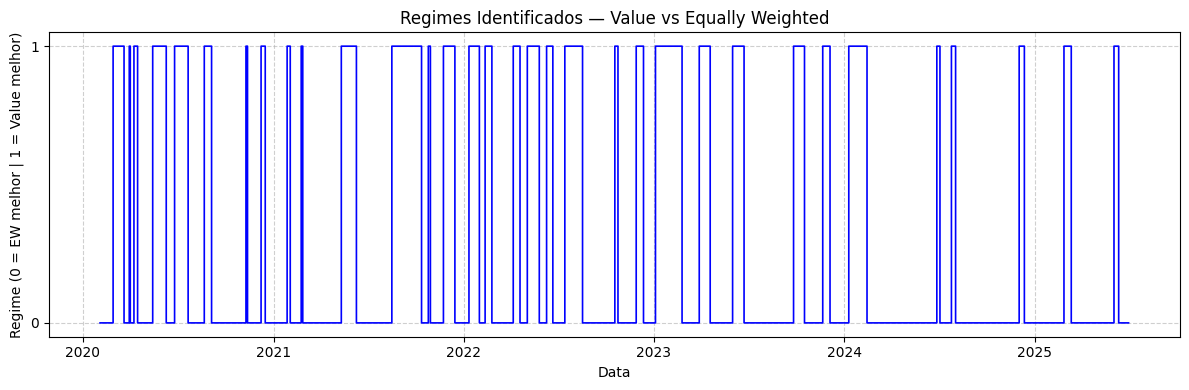

In [22]:
import matplotlib.pyplot as plt

regimes_value = identify_jump_regime_simple(df_value_portfolio, df_ew_portfolio,
                                spans=(1,5,10),
                                lambda_jump=8,
                                max_iter=100,
                                tol=1e-6,
                                random_state=1)

plt.figure(figsize=(12, 4))
plt.plot(regimes_value["Date"], regimes_value["Regime"], drawstyle="steps-post", color="blue", lw=1.2)
plt.title("Regimes Identificados — Value vs Equally Weighted")
plt.xlabel("Data")
plt.ylabel("Regime (0 = EW melhor | 1 = Value melhor)")
plt.yticks([0, 1])
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

REGIMES GROWTH

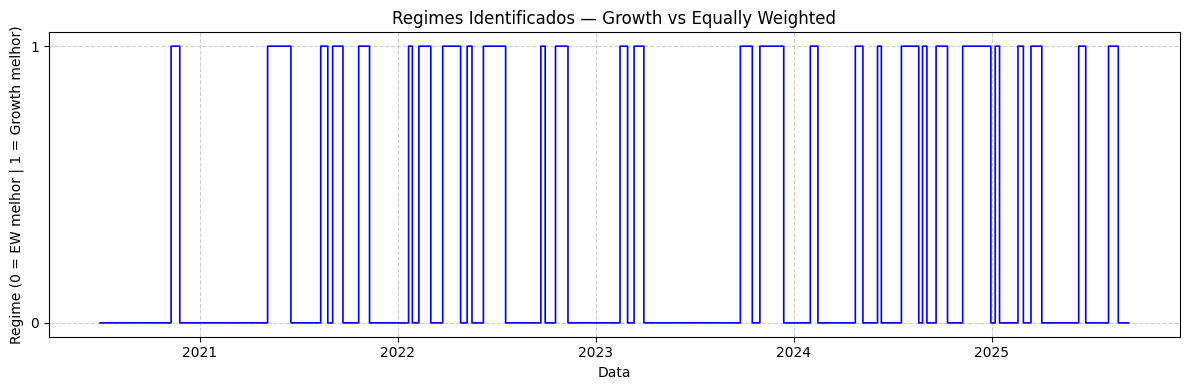

In [23]:
regimes_growth = identify_jump_regime_simple(df_growth_portfolio, df_ew_portfolio,
                                spans=(1,5,10),
                                lambda_jump=8.0,
                                max_iter=100,
                                tol=1e-6,
                                random_state=1)

plt.figure(figsize=(12, 4))
plt.plot(regimes_growth["Date"], regimes_growth["Regime"], drawstyle="steps-post", color="blue", lw=1.2)
plt.title("Regimes Identificados — Growth vs Equally Weighted")
plt.xlabel("Data")
plt.ylabel("Regime (0 = EW melhor | 1 = Growth melhor)")
plt.yticks([0, 1])
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

REGIMES SMALL

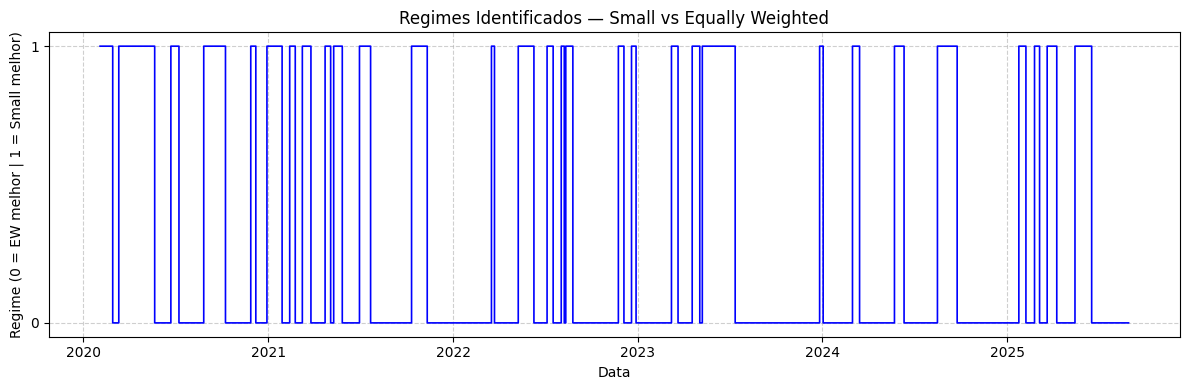

In [24]:
regimes_small = identify_jump_regime_simple(df_small_portfolio, df_ew_portfolio,
                                spans=(1,5,10),
                                lambda_jump=8.0,
                                max_iter=100,
                                tol=1e-6,
                                random_state=1)

plt.figure(figsize=(12, 4))
plt.plot(regimes_small["Date"], regimes_small["Regime"], drawstyle="steps-post", color="blue", lw=1.2)
plt.title("Regimes Identificados — Small vs Equally Weighted")
plt.xlabel("Data")
plt.ylabel("Regime (0 = EW melhor | 1 = Small melhor)")
plt.yticks([0, 1])
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

REGIMES BIG

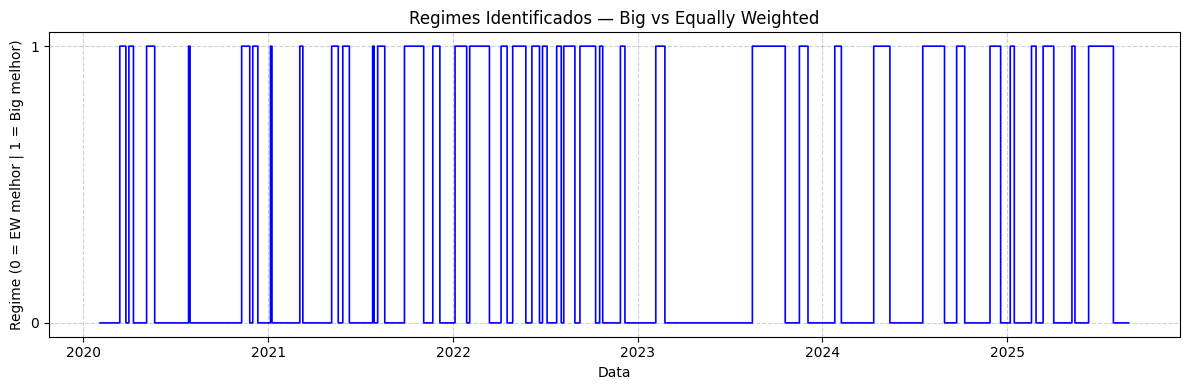

In [25]:
regimes_big = identify_jump_regime_simple(df_big_portfolio, df_ew_portfolio,
                                spans=(1,5,10),
                                lambda_jump=8.0,
                                max_iter=100,
                                tol=1e-6,
                                random_state=1)

plt.figure(figsize=(12, 4))
plt.plot(regimes_big["Date"], regimes_big["Regime"], drawstyle="steps-post", color="blue", lw=1.2)
plt.title("Regimes Identificados — Big vs Equally Weighted")
plt.xlabel("Data")
plt.ylabel("Regime (0 = EW melhor | 1 = Big melhor)")
plt.yticks([0, 1])
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

REGIMES MOMENTUM

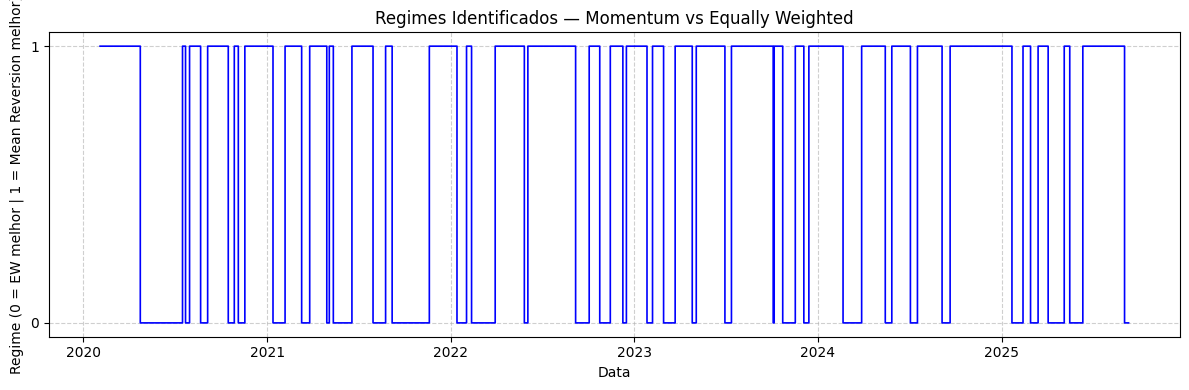

In [26]:
regimes_momentum  = identify_jump_regime_simple(df_momentum_portfolio, df_ew_portfolio,
                                spans=(1,5,10),
                                lambda_jump=8.0,
                                max_iter=100,
                                tol=1e-6,
                                random_state=1)

plt.figure(figsize=(12, 4))
plt.plot(regimes_momentum["Date"], regimes_momentum["Regime"], drawstyle="steps-post", color="blue", lw=1.2)
plt.title("Regimes Identificados — Momentum vs Equally Weighted")
plt.xlabel("Data")
plt.ylabel("Regime (0 = EW melhor | 1 = Mean Reversion melhor)")
plt.yticks([0, 1])
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

REGIMES MEAN REVERSION

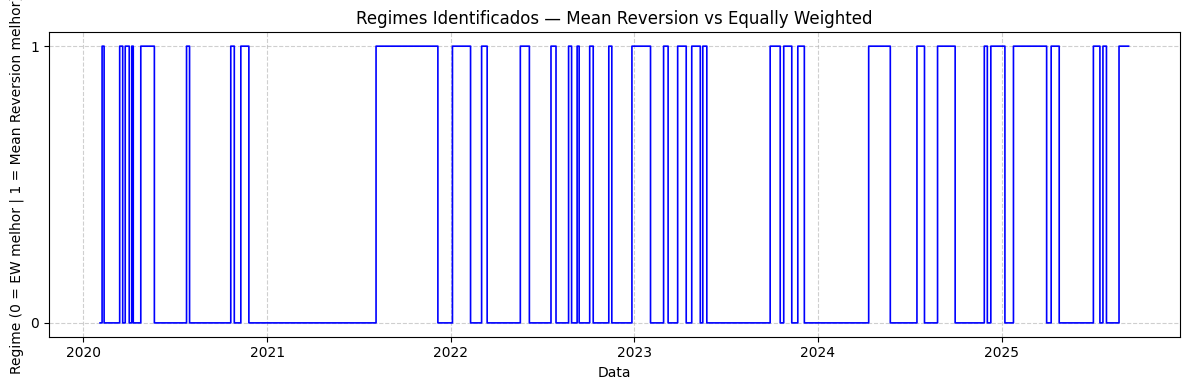

In [27]:
regimes_meanrev = identify_jump_regime_simple(df_meanrev_portfolio, df_ew_portfolio,
                                spans=(1,5,10),
                                lambda_jump=8.0,
                                max_iter=100,
                                tol=1e-6,
                                random_state=1)

plt.figure(figsize=(12, 4))
plt.plot(regimes_meanrev["Date"], regimes_meanrev["Regime"], drawstyle="steps-post", color="blue", lw=1.2)
plt.title("Regimes Identificados — Mean Reversion vs Equally Weighted")
plt.xlabel("Data")
plt.ylabel("Regime (0 = EW melhor | 1 = Mean Reversion melhor)")
plt.yticks([0, 1])
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### XGBoost

BASE MACRO

In [29]:
# Carregando as bases
brent = pd.read_excel("Brent.xlsx", sheet_name="Daily")
juros = pd.read_excel("juros3meses.xlsx", sheet_name="Séries")
cambio = pd.read_excel("cambion.xlsx", sheet_name="Séries")

# Limpando as bases 
# CÂMBIO 
cambio['Date'] = pd.to_datetime(cambio['Data'], dayfirst=True)
cambio_clean = cambio[['Date', cambio.columns[1]]].copy()  
cambio_clean.columns = ['Date', 'cambio_nominal']
cambio_clean = cambio_clean.dropna(subset=['cambio_nominal'])
cambio_clean = cambio_clean[cambio_clean['cambio_nominal'] > 0.01]

# JUROS 
juros['Date'] = pd.to_datetime(juros['Data'], dayfirst=True)
juros_clean = juros[['Date', juros.columns[1]]].copy()  
juros_clean.columns = ['Date', 'juros3m']
juros_clean = juros_clean.dropna(subset=['juros3m'])

# BRENT
brent_clean = brent[['observation_date', 'DCOILBRENTEU']].copy()
brent_clean.columns = ['Date', 'brent']
brent_clean = brent_clean.dropna(subset=['brent'])
print(f"Brent limpo: {brent_clean.shape}")

# Juntando as bases
print("\n=== JUNTANDO BASES ===")
macro_final = cambio_clean.set_index('Date')

macro_final = macro_final.merge(
    juros_clean.set_index('Date'), 
    left_index=True, 
    right_index=True, 
    how='left'
)

macro_final = macro_final.merge(
    brent_clean.set_index('Date'), 
    left_index=True, 
    right_index=True, 
    how='left'
)

print(f"Base combinada: {macro_final.shape}")

# Encontrar período com dados completos
first_complete = macro_final.dropna().index.min()
macro_complete = macro_final.loc[first_complete:].dropna()

print(f"\n✅ Base completa a partir de: {first_complete}")
print(f"✅ Período: {macro_complete.index.min()} a {macro_complete.index.max()}")
print(f"✅ Shape final: {macro_complete.shape}")

print("\n=== DADOS MISSING NA BASE ORIGINAL ===")
print(macro_final.isnull().sum())

print("\n=== AMOSTRA DOS DADOS COMPLETOS ===")
macro_complete

Brent limpo: (9719, 2)

=== JUNTANDO BASES ===
Base combinada: (8982, 3)

✅ Base completa a partir de: 2000-04-04 00:00:00
✅ Período: 2000-04-04 00:00:00 a 2025-09-08 00:00:00
✅ Shape final: (6264, 3)

=== DADOS MISSING NA BASE ORIGINAL ===
cambio_nominal       0
juros3m           2599
brent              205
dtype: int64

=== AMOSTRA DOS DADOS COMPLETOS ===


,cambio_nominal,juros3m,brent
Date,,,
2000-04-04,1.7417,18.5657,23.26
2000-04-05,1.7524,18.7533,22.98
2000-04-06,1.7415,18.8567,22.90
2000-04-07,1.7431,18.6807,22.63
2000-04-10,1.7379,18.6809,21.08
...,...,...,...
2025-09-02,5.4674,14.9043,68.09
2025-09-03,5.4479,14.8944,67.76
2025-09-04,5.4581,14.8851,66.41


FUNÇÃO PARA CRIAR FEATURES DO XGBOOST 

In [30]:
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# FUNÇÃO PARA CRIAR FEATURES DO XGBOOST 
# =============================================================================

class XGBoostRegimeForecasterFinal:
    def __init__(self):
        self.model = None
        self.scaler = StandardScaler()
        self.feature_names = None
        self.class_weights = None
        
    def calculate_class_weights(self, y):
        """Calcula pesos balanceados para classes desbalanceadas"""
        unique, counts = np.unique(y, return_counts=True)
        n_samples = len(y)
        n_classes = len(unique)
        
        weights = {}
        for i, cls in enumerate(unique):
            weights[cls] = n_samples / (n_classes * counts[i])
        
        return weights
    
    def train(self, X_train, y_train):
        """
        Treina modelo XGBoost com correção para problemas de balanceamento
        """
        # Calcular pesos das classes
        self.class_weights = self.calculate_class_weights(y_train)
        
        # Parâmetros 
        params = {
            'objective': 'binary:logistic',
            'max_depth': 4,           
            'learning_rate': 0.1,
            'n_estimators': 150,      
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'reg_alpha': 0.3,         
            'reg_lambda': 0.8,        
            'min_child_weight': 2,
            'scale_pos_weight': self.class_weights.get(1, 1),
            'random_state': 42,
            'eval_metric': 'logloss'
        }
        
        self.model = xgb.XGBClassifier(**params)
        self.model.fit(X_train, y_train)
    
    def predict(self, X, threshold=0.5):
        """Previsões com threshold ajustável"""
        X_scaled = self.scaler.transform(X)
        probabilities = self.model.predict_proba(X_scaled)[:, 1]
        
        # Aplicar threshold dinâmico baseado na distribuição
        if len(probabilities) > 0:
            # Threshold mais agressivo para melhor balanceamento
            dynamic_threshold = max(0.4, min(0.6, np.percentile(probabilities, 55)))
            return (probabilities > dynamic_threshold).astype(int)
        else:
            return np.array([])
    
    def predict_proba(self, X):
        X_scaled = self.scaler.transform(X)
        return self.model.predict_proba(X_scaled)
    
    def get_feature_importance(self):
        if self.model is None:
            return pd.DataFrame()
        
        importance_df = pd.DataFrame({
            'feature': self.feature_names,
            'importance': self.model.feature_importances_
        }).sort_values('importance', ascending=False)
        return importance_df

CLASSE DO MODELO XGBOOST

In [31]:
# =============================================================================
# CLASSE DO MODELO XGBOOST
# =============================================================================

def create_features_optimized(factor_returns, ew_returns, macro_data, regime_labels, factor_name):
    """
    Cria features OTIMIZADA para todos os fatores
    """
    print(f"   🛠️  Criando features para {factor_name}...")
    
    # Período comum
    start_date = max([
        factor_returns.index.min(),
        ew_returns.index.min(), 
        macro_data.index.min(),
        regime_labels['Date'].min()
    ])
    
    end_date = min([
        factor_returns.index.max(),
        ew_returns.index.max(),
        macro_data.index.max(),
        regime_labels['Date'].max()
    ])
    
    if start_date >= end_date:
        return pd.DataFrame()
    
    # Filtrar e alinhar dados
    factor_filtrado = factor_returns.loc[start_date:end_date]
    ew_filtrado = ew_returns.loc[start_date:end_date]
    macro_filtrado = macro_data.loc[start_date:end_date]
    regime_filtrado = regime_labels[
        (regime_labels['Date'] >= start_date) & 
        (regime_labels['Date'] <= end_date)
    ]
    
    # Índices comuns
    common_idx = (factor_filtrado.index
                 .intersection(ew_filtrado.index)
                 .intersection(macro_filtrado.index)
                 .intersection(pd.to_datetime(regime_filtrado['Date'])))
    
    if len(common_idx) == 0:
        return pd.DataFrame()
    
    # Alinhar dados
    factor_aligned = factor_filtrado.loc[common_idx]
    ew_aligned = ew_filtrado.loc[common_idx]
    macro_aligned = macro_filtrado.loc[common_idx]
    regime_aligned = regime_filtrado.set_index('Date').loc[common_idx]
    
    # DataFrame para features
    features_df = pd.DataFrame(index=common_idx)
    
    # FEATURES OTIMIZADAS
    long_short_returns = factor_aligned['Return'] - ew_aligned['Portfolio_Return']
    
    # A. Features de retorno com múltiplos lags
    spans = [5, 10, 21, 42, 63]  
    for span in spans:
        features_df[f'ls_ewma_{span}'] = long_short_returns.ewm(span=span).mean().shift(1)
        
        # Downside deviation
        downside = np.where(long_short_returns < 0, long_short_returns, 0)
        features_df[f'ls_ewmdd_{span}'] = pd.Series(downside).ewm(span=span).std().shift(1)
    
    # B. Features de momentum adicional
    features_df['ls_ret_1d'] = long_short_returns.shift(1)
    features_df['ls_ret_5d'] = long_short_returns.rolling(5).mean().shift(1)
    
    # C. Features macro expandidas
    macro_features = ['cambio_nominal', 'juros3m', 'brent']
    for feature in macro_features:
        if feature in macro_aligned.columns:
            # Múltiplas janelas
            for span in [5, 21, 63]:
                features_df[f'{feature}_ewma_{span}'] = macro_aligned[feature].ewm(span=span).mean().shift(1)
            
            features_df[f'{feature}_diff_1d'] = macro_aligned[feature].diff().shift(1)
            features_df[f'{feature}_diff_5d'] = macro_aligned[feature].diff(5).shift(1)
    
    # D. Volatilidade do fator
    features_df['factor_vol_21d'] = factor_aligned['Return'].rolling(21).std().shift(1)
    features_df['market_vol_21d'] = ew_aligned['Portfolio_Return'].rolling(21).std().shift(1)
    
    # E. Target - regime do próximo dia
    features_df['target'] = regime_aligned['Regime'].shift(-1)
    
    # LIMPEZA 
    features_df = features_df.dropna(subset=['target'])
    
    # Verificar balanceamento
    target_dist = features_df['target'].value_counts()
    balance_ratio = target_dist.min() / target_dist.max() if len(target_dist) == 2 else 0
    
    print(f"   📊 {factor_name}: {len(features_df)} obs | Balanceamento: {features_df['target'].mean():.3f} (ratio: {balance_ratio:.3f})")
    
    # Preencher NaN de forma robusta
    for col in features_df.columns:
        if col != 'target' and features_df[col].isnull().any():
            # Preencher com mediana da janela rolling para preservar estrutura temporal
            features_df[col] = features_df[col].fillna(features_df[col].rolling(10, min_periods=1).median())
    
    features_df = features_df.fillna(0)  # Último recurso
    features_df = features_df.dropna()
    features_df['target'] = features_df['target'].astype(int)
    
    return features_df

VALIDAÇÃO EM JANELA MÓVEL

In [35]:
# =============================================================================
# VALIDAÇÃO EM JANELA MÓVEL
# =============================================================================

def rolling_validation_optimized(features_df, factor_name, train_years=2, test_days=21):
    """
    Validação em janela móvel OTIMIZADA
    """
    features_df = features_df.sort_index()
    
    if len(features_df) < 400:  
        print(f"   ⚠️  Dados insuficientes para {factor_name}: {len(features_df)} observações")
        return pd.DataFrame(), pd.DataFrame()
    
    forecasts = []
    feature_importance_data = []
    
    all_dates = features_df.index.sort_values()
    start_date = all_dates[0]
    end_date = all_dates[-1]
    
    current_test_start = start_date + pd.DateOffset(years=train_years)
    
    print(f"   🔄 Validação: {train_years} anos treino + {test_days} dias teste")
    
    window_count = 0
    successful_windows = 0
    
    while current_test_start + pd.DateOffset(days=test_days) <= end_date:
        # Definir períodos
        train_end = current_test_start - pd.DateOffset(days=1)
        train_start = train_end - pd.DateOffset(years=train_years) + pd.DateOffset(days=1)
        
        test_start = current_test_start
        test_end = current_test_start + pd.DateOffset(days=test_days - 1)
        
        # Separar dados
        train_mask = (features_df.index >= train_start) & (features_df.index <= train_end)
        test_mask = (features_df.index >= test_start) & (features_df.index <= test_end)
        
        X_train = features_df[train_mask].drop('target', axis=1)
        y_train = features_df[train_mask]['target']
        X_test = features_df[test_mask].drop('target', axis=1)
        y_test = features_df[test_mask]['target']
        
        # Verificações mais rigorosas
        min_train_samples = 150
        min_test_samples = 10
        min_class_samples = 5
        
        if (len(X_train) >= min_train_samples and len(X_test) >= min_test_samples and 
            y_train.nunique() > 1 and y_test.nunique() > 1 and
            (y_train == 0).sum() >= min_class_samples and (y_train == 1).sum() >= min_class_samples):
            
            try:
                # Treinar modelo
                forecaster = XGBoostRegimeForecasterFinal()
                forecaster.feature_names = X_train.columns.tolist()
                
                # Padronizar e treinar
                X_train_scaled = forecaster.scaler.fit_transform(X_train)
                X_test_scaled = forecaster.scaler.transform(X_test)
                
                forecaster.train(X_train_scaled, y_train)
                
                # Previsões
                y_pred = forecaster.predict(X_test_scaled)
                
                # Pular janela se todas as previsões forem da mesma classe
                if len(np.unique(y_pred)) == 1:
                    current_test_start = test_end + pd.DateOffset(days=1)
                    continue
                
                y_proba = forecaster.predict_proba(X_test_scaled)
                
                # Verificar distribuição das previsões
                pred_dist = pd.Series(y_pred).value_counts()
                
                window_results = pd.DataFrame({
                    'date': X_test.index,
                    'actual_regime': y_test.values,
                    'predicted_regime': y_pred,
                    'probability_regime_1': y_proba[:, 1],
                    'factor': factor_name
                })
                forecasts.append(window_results)
                
                # Importância das features
                importance_df = forecaster.get_feature_importance()
                importance_df['window_end'] = current_test_start
                importance_df['factor'] = factor_name
                feature_importance_data.append(importance_df)
                
                accuracy = accuracy_score(y_test, y_pred)
                regime_1_accuracy = (y_test[y_test == 1] == y_pred[y_test == 1]).mean() if (y_test == 1).sum() > 0 else 0
                regime_0_accuracy = (y_test[y_test == 0] == y_pred[y_test == 0]).mean() if (y_test == 0).sum() > 0 else 0
                
                if window_count % 10 == 0:  # Print a cada 10 janelas 
                    print(f"      ✅ Janela {window_count+1}: {test_start.date()} | "
                          f"Acc: {accuracy:.3f} | R1: {regime_1_accuracy:.3f} | R0: {regime_0_accuracy:.3f}")
                
                successful_windows += 1
                window_count += 1
                
            except Exception as e:
                # Silenciar erros individuais, continuar processamento
                pass
        
        # Próxima janela
        current_test_start = test_end + pd.DateOffset(days=1)
    
    print(f"   🎯 {successful_windows}/{window_count} janelas processadas com sucesso")
    
    if forecasts:
        return pd.concat(forecasts), pd.concat(feature_importance_data)
    return pd.DataFrame(), pd.DataFrame()

APLICAR PARA CADA FATOR

In [38]:
# =============================================================================
# APLICAR PARA CADA FATOR
# =============================================================================

fatores = {
    'value': (df_value_portfolio, regimes_value),
    'growth': (df_growth_portfolio, regimes_growth), 
    'small': (df_small_portfolio, regimes_small),
    'big': (df_big_portfolio, regimes_big),
    'momentum': (df_momentum_portfolio, regimes_momentum),
    'meanrev': (df_meanrev_portfolio, regimes_meanrev)
}


print("=== XGBOOST FINAL - TODOS OS FATORES ===")

# Lista completa de fatores
# Lista completa de fatores - CORRIGIDA
todos_fatores = ['value', 'growth', 'small', 'big', 'momentum', 'meanrev']
resultados_finais = {}
estatisticas_gerais = []

for fator_name in todos_fatores:
    if fator_name in fatores:
        print(f"\n{'='*60}")
        print(f"🎯 PROCESSANDO: {fator_name.upper()}")
        print(f"{'='*60}")
        
        portfolio_ret, regime_labels = fatores[fator_name]
        
        # Criar features 
        features_df = create_features_optimized(
            portfolio_ret, 
            df_ew_portfolio, 
            macro_complete, 
            regime_labels, 
            fator_name
        )
        
        if len(features_df) > 400:
            print(f"📊 {fator_name}: {len(features_df)} observações | Iniciando validação...")
            
            # Validação 
            forecasts, feature_importance = rolling_validation_optimized(features_df, fator_name)
            
            if len(forecasts) > 0:
                accuracy = accuracy_score(forecasts['actual_regime'], forecasts['predicted_regime'])
                
                regime_1_mask = forecasts['actual_regime'] == 1
                regime_0_mask = forecasts['actual_regime'] == 0
                
                regime_1_accuracy = (forecasts[regime_1_mask]['predicted_regime'] == 1).mean() if regime_1_mask.sum() > 0 else 0
                regime_0_accuracy = (forecasts[regime_0_mask]['predicted_regime'] == 0).mean() if regime_0_mask.sum() > 0 else 0
                
                # Distribuição das previsões
                pred_dist = forecasts['predicted_regime'].value_counts()
                pred_ratio = pred_dist.min() / pred_dist.max() if len(pred_dist) == 2 else 0
                
                print(f"✅ {fator_name.upper()} - RESULTADOS FINAIS:")
                print(f"   📈 Acurácia: {accuracy:.4f}")
                print(f"   🔍 Regime 1: {regime_1_accuracy:.4f} | Regime 0: {regime_0_accuracy:.4f}")
                print(f"   📊 Previsões: {pred_dist.to_dict()} (ratio: {pred_ratio:.3f})")
                print(f"   📅 Total de previsões: {len(forecasts)}")
                
                resultados_finais[fator_name] = {
                    'forecasts': forecasts,
                    'feature_importance': feature_importance,
                    'accuracy': accuracy,
                    'regime_1_accuracy': regime_1_accuracy,
                    'regime_0_accuracy': regime_0_accuracy,
                    'prediction_balance': pred_ratio
                }
                
                # Estatísticas para ranking
                estatisticas_gerais.append({
                    'Fator': fator_name.upper(),
                    'Acurácia': accuracy,
                    'Regime_1_Acc': regime_1_accuracy,
                    'Regime_0_Acc': regime_0_accuracy,
                    'Balanceamento': pred_ratio,
                    'Previsões': len(forecasts)
                })
                
            else:
                print(f"⚠️  {fator_name}: Nenhuma previsão gerada na validação")
        else:
            print(f"❌ {fator_name}: Dados insuficientes após processamento ({len(features_df)} observações)")

=== XGBOOST FINAL - TODOS OS FATORES ===

🎯 PROCESSANDO: VALUE
   🛠️  Criando features para value...
   📊 value: 1320 obs | Balanceamento: 0.297 (ratio: 0.422)
📊 value: 1320 observações | Iniciando validação...
   🔄 Validação: 2 anos treino + 21 dias teste
      ✅ Janela 1: 2022-10-13 | Acc: 0.714 | R1: 0.500 | R0: 0.800
      ✅ Janela 11: 2024-07-25 | Acc: 0.800 | R1: 0.800 | R0: 0.800
   🎯 15/15 janelas processadas com sucesso
✅ VALUE - RESULTADOS FINAIS:
   📈 Acurácia: 0.5952
   🔍 Regime 1: 0.4250 | Regime 0: 0.7000
   📊 Previsões: {0: 137, 1: 73} (ratio: 0.533)
   📅 Total de previsões: 210

🎯 PROCESSANDO: GROWTH
   🛠️  Criando features para growth...
   📊 growth: 1271 obs | Balanceamento: 0.301 (ratio: 0.431)
📊 growth: 1271 observações | Iniciando validação...
   🔄 Validação: 2 anos treino + 21 dias teste
      ✅ Janela 1: 2022-07-01 | Acc: 0.600 | R1: 0.545 | R0: 0.750
      ✅ Janela 11: 2025-01-31 | Acc: 0.867 | R1: 0.500 | R0: 1.000
   🎯 16/16 janelas processadas com sucesso
✅ G

Resultados

In [39]:
# =============================================================================
# RELATÓRIO FINAL COMPLETO
# =============================================================================

print("\n" + "="*80)
print("📊 RELATÓRIO FINAL - TODOS OS FATORES")
print("="*80)

if resultados_finais:
    # Criar DataFrame de estatísticas
    stats_df = pd.DataFrame(estatisticas_gerais)
    
    # Ordenar por acurácia
    stats_df = stats_df.sort_values('Acurácia', ascending=False)
    
    print("\n🏆 RANKING POR ACURÁCIA:")
    print(stats_df.round(4).to_string(index=False))
    
    print(f"\n📈 ESTATÍSTICAS GERAIS:")
    print(f"   ✅ Fatores processados: {len(resultados_finais)}/{len(todos_fatores)}")
    print(f"   📊 Acurácia média: {stats_df['Acurácia'].mean():.4f}")
    print(f"   🔍 Regime 1 acurácia média: {stats_df['Regime_1_Acc'].mean():.4f}")
    print(f"   🔍 Regime 0 acurácia média: {stats_df['Regime_0_Acc'].mean():.4f}")
    print(f"   ⚖️  Balanceamento médio: {stats_df['Balanceamento'].mean():.4f}")
    
    # Análise de features mais importantes
    print(f"\n🔍 TOP 10 FEATURES MAIS IMPORTANTES (GLOBAL):")
    all_importance = pd.concat([r['feature_importance'] for r in resultados_finais.values()])
    top_features = all_importance.groupby('feature')['importance'].mean().sort_values(ascending=False).head(10)
    
    for i, (feature, importance) in enumerate(top_features.items(), 1):
        print(f"   {i:2d}. {feature:<25} {importance:.4f}")
    
    # Verificar qualidade geral
    problemas_detectados = stats_df[stats_df['Balanceamento'] < 0.3]
    if len(problemas_detectados) > 0:
        print(f"\n⚠️  AVISO: {len(problemas_detectados)} fator(es) com possível desbalanceamento:")
        for _, row in problemas_detectados.iterrows():
            print(f"   - {row['Fator']}: balanceamento = {row['Balanceamento']:.3f}")
    
    print(f"\n🎉 PROCESSAMENTO CONCLUÍDO COM SUCESSO!")
    
else:
    print("❌ Nenhum fator foi processado com sucesso")

# =============================================================================
# ANÁLISE DE PERFORMANCE DAS ESTRATÉGIAS
# =============================================================================

def analyze_trading_performance(forecasts, portfolio_returns, ew_returns, factor_name, transaction_cost=0.0005):
    """
    Analisa performance da estratégia de trading baseada nos regimes previstos
    """
    strategy_data = forecasts.set_index('date').copy()
    
    # Garantir alinhamento temporal
    strategy_data = strategy_data.join(portfolio_returns[['Return']], how='left')
    strategy_data = strategy_data.join(ew_returns[['Portfolio_Return']], how='left')
    
    # Preencher valores faltantes
    strategy_data[['Return', 'Portfolio_Return']] = strategy_data[['Return', 'Portfolio_Return']].fillna(0)
    
    # Estratégia: Se regime 1 previsto -> investe no fator, senão no benchmark
    strategy_data['position'] = strategy_data['predicted_regime']
    strategy_data['strategy_return'] = np.where(
        strategy_data['position'] == 1,
        strategy_data['Return'],
        strategy_data['Portfolio_Return']
    )
    
    # Aplicar custo de transação (5 bps como no paper)
    strategy_data['position_change'] = strategy_data['position'].diff().fillna(0).abs()
    strategy_data['strategy_return_net'] = strategy_data['strategy_return'] - (
        strategy_data['position_change'] * transaction_cost
    )
    
    # Calcular métricas de performance
    returns_net = strategy_data['strategy_return_net']
    returns_benchmark = strategy_data['Portfolio_Return']
    
    if len(returns_net) == 0:
        return None
    
    # Métricas básicas
    total_return_strategy = (1 + returns_net).prod() - 1
    total_return_benchmark = (1 + returns_benchmark).prod() - 1
    excess_return = total_return_strategy - total_return_benchmark
    
    # Sharpe Ratio (assumindo risco livre = 0 para simplificar)
    sharpe_strategy = returns_net.mean() / returns_net.std() * np.sqrt(252) if returns_net.std() > 0 else 0
    
    # Maximum Drawdown
    cumulative_strategy = (1 + returns_net).cumprod()
    running_max = cumulative_strategy.expanding().max()
    drawdown = (cumulative_strategy - running_max) / running_max
    max_drawdown = drawdown.min()
    
    # Win Rate
    win_rate = (returns_net > 0).mean()
    
    return {
        'Fator': factor_name.upper(),
        'Sharpe_Strategy': sharpe_strategy,
        'Return_Strategy': total_return_strategy,
        'Excess_Benchmark': excess_return,
        'Max_Drawdown': max_drawdown,
        'Win_Rate': win_rate,
        'n_observations': len(returns_net)
    }

# =============================================================================
# GERAR RELATÓRIO FINAL COMPLETO
# =============================================================================

print("\n" + "="*100)
print("📊 RELATÓRIO FINAL - TODOS OS FATORES COM ANÁLISE DE PERFORMANCE")
print("="*100)

if resultados_finais:
    # Analisar performance de trading para cada fator
    performance_results = []
    
    for fator_name, resultados in resultados_finais.items():
        if fator_name in fatores:
            print(f"📈 Analisando performance de trading para {fator_name.upper()}...")
            
            portfolio_ret = fatores[fator_name][0]
            performance = analyze_trading_performance(
                resultados['forecasts'], 
                portfolio_ret, 
                df_ew_portfolio,
                fator_name
            )
            
            if performance:
                performance_results.append(performance)
    
    # Criar DataFrame de performance
    if performance_results:
        performance_df = pd.DataFrame(performance_results)
        
        # Ordenar por Sharpe Ratio
        performance_df = performance_df.sort_values('Sharpe_Strategy', ascending=False)
        
        print("\n" + "="*90)
        print("🏆 RANKING POR SHARPE RATIO (ESTRATÉGIA):")
        print("="*90)
        
        # Formatar a tabela para melhor visualização
        display_df = performance_df[[
            'Fator', 'Sharpe_Strategy', 'Return_Strategy', 
            'Excess_Benchmark', 'Max_Drawdown', 'Win_Rate'
        ]].round(4)
        
        # Renomear colunas para melhor apresentação
        display_df = display_df.rename(columns={
            'Sharpe_Strategy': 'Sharpe_Strategy',
            'Return_Strategy': 'Return_Strategy', 
            'Excess_Benchmark': 'Excess_Benchmark',
            'Max_Drawdown': 'Max_Drawdown',
            'Win_Rate': 'Win_Rate'
        })
        
        print(display_df.to_string(index=False))
        
        # Estatísticas gerais de performance
        print(f"\n📈 ESTATÍSTICAS GERAIS DE PERFORMANCE:")
        print(f"   📊 Sharpe Ratio médio: {performance_df['Sharpe_Strategy'].mean():.4f}")
        print(f"   💰 Retorno médio da estratégia: {performance_df['Return_Strategy'].mean():.4f}")
        print(f"   📈 Excess return médio: {performance_df['Excess_Benchmark'].mean():.4f}")
        print(f"   📉 Maximum Drawdown médio: {performance_df['Max_Drawdown'].mean():.4f}")
        print(f"   🎯 Win Rate médio: {performance_df['Win_Rate'].mean():.4f}")
        
        # Análise dos melhores e piores performers
        best_sharpe = performance_df.iloc[0]
        worst_sharpe = performance_df.iloc[-1]
        
        print(f"\n🔥 MELHOR PERFORMER:")
        print(f"   {best_sharpe['Fator']} - Sharpe: {best_sharpe['Sharpe_Strategy']:.4f}, "
              f"Retorno: {best_sharpe['Return_Strategy']:.4f}, "
              f"Excess: {best_sharpe['Excess_Benchmark']:.4f}")
        
        print(f"\n❌ PIOR PERFORMER:")
        print(f"   {worst_sharpe['Fator']} - Sharpe: {worst_sharpe['Sharpe_Strategy']:.4f}, "
              f"Retorno: {worst_sharpe['Return_Strategy']:.4f}, "
              f"Excess: {worst_sharpe['Excess_Benchmark']:.4f}")
        
        # Análise de acurácia vs performance
        accuracy_vs_performance = []
        for fator_name, resultados in resultados_finais.items():
            if fator_name in [f.lower() for f in performance_df['Fator']]:
                perf_row = performance_df[performance_df['Fator'] == fator_name.upper()].iloc[0]
                accuracy_vs_performance.append({
                    'Fator': fator_name.upper(),
                    'Accuracy': resultados['accuracy'],
                    'Sharpe': perf_row['Sharpe_Strategy'],
                    'Return': perf_row['Return_Strategy']
                })
        
        acc_perf_df = pd.DataFrame(accuracy_vs_performance)
        correlation = acc_perf_df['Accuracy'].corr(acc_perf_df['Sharpe'])
        
        print(f"\n🔗 CORRELAÇÃO Acuracia x Sharpe: {correlation:.4f}")
        
        if correlation > 0.3:
            print("   ✅ Boa correlação: modelos mais precisos geram melhor performance")
        elif correlation < -0.3:
            print("   ⚠️  Correlação negativa: verificar overfitting")
        else:
            print("   🔄 Correlação fraca: performance não depende apenas da acurácia")

    else:
        print("❌ Nenhuma análise de performance pôde ser realizada")
    
else:
    print("❌ Nenhum resultado disponível para análise de performance")

print(f"\n🎉 ANÁLISE DE PERFORMANCE CONCLUÍDA!")


📊 RELATÓRIO FINAL - TODOS OS FATORES

🏆 RANKING POR ACURÁCIA:
   Fator  Acurácia  Regime_1_Acc  Regime_0_Acc  Balanceamento  Previsões
MOMENTUM    0.7063        0.8497        0.4848         0.3923        252
  GROWTH    0.6444        0.6404        0.6486         0.9912        225
     BIG    0.6313        0.4512        0.8000         0.4739        339
   SMALL    0.6177        0.5833        0.6416         0.8199        293
   VALUE    0.5952        0.4250        0.7000         0.5328        210
 MEANREV    0.5476        0.3284        0.6931         0.4609        168

📈 ESTATÍSTICAS GERAIS:
   ✅ Fatores processados: 6/6
   📊 Acurácia média: 0.6238
   🔍 Regime 1 acurácia média: 0.5463
   🔍 Regime 0 acurácia média: 0.6614
   ⚖️  Balanceamento médio: 0.6118

🔍 TOP 10 FEATURES MAIS IMPORTANTES (GLOBAL):
    1. ls_ewma_10                0.1965
    2. ls_ewma_21                0.1125
    3. ls_ewma_5                 0.0602
    4. juros3m_ewma_21           0.0421
    5. ls_ewma_42            

Estrategia Inicial

In [40]:
# =============================================================================
# IMPLEMENTAÇÃO DAS ESTRATÉGIAS DE TRADING INICIAL
# =============================================================================

def implementar_estrategia_trading(forecasts, portfolio_returns, ew_returns, factor_name, strategy_type="active"):
    """
    Implementa estratégias de trading baseadas nos regimes previstos
    Conforme Paper Sections 5 (Active) e 6 (Complementary)
    """
    strategy_data = forecasts.set_index('date').copy()
    
    # Garantir alinhamento temporal
    strategy_data = strategy_data.join(portfolio_returns[['Return']], how='left')
    strategy_data = strategy_data.join(ew_returns[['Portfolio_Return']], how='left')
    
    # Preencher valores faltantes
    strategy_data[['Return', 'Portfolio_Return']] = strategy_data[['Return', 'Portfolio_Return']].fillna(0)
    
    if strategy_type == "active":
        # ESTRATÉGIA ATIVA 
        # Se regime 1 -> investe no fator, senão no benchmark
        strategy_data['position'] = strategy_data['predicted_regime']
        strategy_data['strategy_return'] = np.where(
            strategy_data['position'] == 1,
            strategy_data['Return'],
            strategy_data['Portfolio_Return']
        )
        
    elif strategy_type == "complementary":
        # ESTRATÉGIA COMPLEMENTAR 
        # Para pares de fatores complementares
        # Versão simplificada 
        strategy_data['position'] = strategy_data['predicted_regime']
        strategy_data['strategy_return'] = np.where(
            strategy_data['position'] == 1,
            strategy_data['Return'],
            strategy_data['Portfolio_Return']
        )
    
    # Aplicar custo de transação 
    strategy_data['position_change'] = strategy_data['position'].diff().fillna(0).abs()
    strategy_data['strategy_return_net'] = strategy_data['strategy_return'] - (
        strategy_data['position_change'] * 0.0005  # 5 bps
    )
    
    return strategy_data

def calcular_metricas_performance(returns_series, benchmark_series, factor_name):
    """
    Calcula métricas de performance completas conforme paper
    """
    if len(returns_series) == 0:
        return None
    
    # Métricas básicas
    total_return = (1 + returns_series).prod() - 1
    total_benchmark = (1 + benchmark_series).prod() - 1
    excess_return = total_return - total_benchmark
    
    # Sharpe Ratio (annualizado)
    sharpe_ratio = returns_series.mean() / returns_series.std() * np.sqrt(252) if returns_series.std() > 0 else 0
    
    # Maximum Drawdown
    cumulative_returns = (1 + returns_series).cumprod()
    running_max = cumulative_returns.expanding().max()
    drawdown = (cumulative_returns - running_max) / running_max
    max_drawdown = drawdown.min()
    
    # Volatilidade (annualizada)
    volatility = returns_series.std() * np.sqrt(252)
    
    # Win Rate
    win_rate = (returns_series > 0).mean()
    
    # Calmar Ratio
    calmar_ratio = total_return / abs(max_drawdown) if max_drawdown != 0 else 0
    
    # Sortino Ratio (só considera downside deviation)
    downside_returns = returns_series[returns_series < 0]
    downside_std = downside_returns.std() * np.sqrt(252) if len(downside_returns) > 0 else 0
    sortino_ratio = (returns_series.mean() * 252) / downside_std if downside_std > 0 else 0
    
    return {
        'Fator': factor_name,
        'Sharpe_Ratio': sharpe_ratio,
        'Return_Total': total_return,
        'Excess_Return': excess_return,
        'Max_Drawdown': max_drawdown,
        'Volatilidade': volatility,
        'Win_Rate': win_rate,
        'Calmar_Ratio': calmar_ratio,
        'Sortino_Ratio': sortino_ratio,
        'Observações': len(returns_series)
    }

def backtest_estrategia_completa(resultados_finais, fatores, strategy_type="active"):
    """
    Realiza backtesting completo da estratégia para todos os fatores
    """
    print(f"\n{'='*80}")
    print(f"📊 BACKTESTING - ESTRATÉGIA {strategy_type.upper()}")
    print(f"{'='*80}")
    
    resultados_backtest = []
    
    for fator_name, resultados in resultados_finais.items():
        if fator_name in fatores:
            print(f"🔍 Backtesting {fator_name.upper()}...")
            
            portfolio_ret = fatores[fator_name][0]
            
            # Implementar estratégia
            strategy_data = implementar_estrategia_trading(
                resultados['forecasts'], 
                portfolio_ret, 
                df_ew_portfolio,
                fator_name, 
                strategy_type
            )
            
            if len(strategy_data) > 0:
                # Calcular métricas
                metrics = calcular_metricas_performance(
                    strategy_data['strategy_return_net'],
                    strategy_data['Portfolio_Return'], 
                    fator_name.upper()
                )
                
                if metrics:
                    resultados_backtest.append(metrics)
                    print(f"   ✅ {fator_name.upper()} - Sharpe: {metrics['Sharpe_Ratio']:.4f}")
    
    return pd.DataFrame(resultados_backtest)

# =============================================================================
# ANÁLISE COMPARATIVA DAS ESTRATÉGIAS
# =============================================================================

def analise_comparativa_estrategias(resultados_backtest):
    """
    Análise comparativa entre diferentes estratégias e fatores
    """
    if len(resultados_backtest) == 0:
        return
    
    df = pd.DataFrame(resultados_backtest)
    
    print(f"\n{'='*100}")
    print("🏆 RANKING COMPLETO DE PERFORMANCE")
    print(f"{'='*100}")
    
    # Ordenar por Sharpe Ratio
    df_ranked = df.sort_values('Sharpe_Ratio', ascending=False)
    
    # Formatar para melhor visualização
    display_cols = ['Fator', 'Sharpe_Ratio', 'Return_Total', 'Excess_Return', 
                   'Max_Drawdown', 'Volatilidade', 'Win_Rate']
    
    display_df = df_ranked[display_cols].round(4)
    print(display_df.to_string(index=False))
    
    # Análise dos melhores performers
    print(f"\n🔥 TOP 3 PERFORMERS:")
    for i in range(min(3, len(df_ranked))):
        perf = df_ranked.iloc[i]
        print(f"   {i+1}. {perf['Fator']}: Sharpe {perf['Sharpe_Ratio']:.4f} | "
              f"Return {perf['Return_Total']:.4f} | MDD {perf['Max_Drawdown']:.4f}")
    
    # Estatísticas gerais
    print(f"\n📈 ESTATÍSTICAS GERAIS DA ESTRATÉGIA:")
    print(f"   📊 Sharpe Ratio médio: {df['Sharpe_Ratio'].mean():.4f}")
    print(f"   💰 Retorno médio: {df['Return_Total'].mean():.4f}")
    print(f"   📈 Excess Return médio: {df['Excess_Return'].mean():.4f}")
    print(f"   📉 Maximum Drawdown médio: {df['Max_Drawdown'].mean():.4f}")
    print(f"   🎯 Win Rate médio: {df['Win_Rate'].mean():.4f}")

# =============================================================================
# ANÁLISE DE SENSIBILIDADE A CUSTOS DE TRANSAÇÃO
# =============================================================================

def analise_sensibilidade_custos(resultados_finais, fatores):
    """
    Analisa sensibilidade da estratégia a diferentes custos de transação
    """
    print(f"\n{'='*80}")
    print("💰 ANÁLISE DE SENSIBILIDADE - CUSTOS DE TRANSAÇÃO")
    print(f"{'='*80}")
    
    custos_transacao = [0.0001, 0.0003, 0.0005, 0.0010]  # 1, 3, 5, 10 bps
    
    sensibilidade_results = []
    
    for custo in custos_transacao:
        print(f"\n🔍 Analisando custo de {custo*10000:.0f} bps...")
        custo_results = []
        
        for fator_name, resultados in resultados_finais.items():
            if fator_name in fatores:
                portfolio_ret = fatores[fator_name][0]
                strategy_data = implementar_estrategia_trading(
                    resultados['forecasts'], portfolio_ret, df_ew_portfolio, fator_name
                )
                
                # Aplicar custo específico
                strategy_data['strategy_return_custo'] = (
                    strategy_data['strategy_return'] - 
                    (strategy_data['position_change'] * custo)
                )
                
                metrics = calcular_metricas_performance(
                    strategy_data['strategy_return_custo'],
                    strategy_data['Portfolio_Return'],
                    fator_name.upper()
                )
                
                if metrics:
                    metrics['Custo_Transacao'] = custo
                    custo_results.append(metrics)
        
        if custo_results:
            df_custo = pd.DataFrame(custo_results)
            sharpe_medio = df_custo['Sharpe_Ratio'].mean()
            print(f"   📊 Sharpe Ratio médio: {sharpe_medio:.4f}")
            sensibilidade_results.extend(custo_results)
    
    return pd.DataFrame(sensibilidade_results)

# =============================================================================
# EXECUÇÃO DAS ESTRATÉGIAS INICIAL
# =============================================================================
if resultados_finais:
    print("\n" + "="*100)
    print("🚀 EXECUTANDO ESTRATÉGIAS DE TRADING")
    print("="*100)
    
    # 1. BACKTESTING DA ESTRATÉGIA ATIVA
    resultados_active = backtest_estrategia_completa(resultados_finais, fatores, "active")
    
    if len(resultados_active) > 0:
        analise_comparativa_estrategias(resultados_active)
    
    # 2. ANÁLISE DE SENSIBILIDADE A CUSTOS
    sensibilidade_df = analise_sensibilidade_custos(resultados_finais, fatores)
    
    # 3. COMPARAÇÃO COM ESTRATÉGIA BUY-AND-HOLD
    print(f"\n{'='*80}")
    print("📊 COMPARAÇÃO COM ESTRATÉGIA BUY-AND-HOLD")
    print(f"{'='*80}")
    
    buy_hold_results = []
    for fator_name in resultados_finais.keys():
        if fator_name in fatores:
            portfolio_ret = fatores[fator_name][0]
            # Estratégia buy-and-hold simples
            metrics = calcular_metricas_performance(
                portfolio_ret['Return'],
                df_ew_portfolio['Portfolio_Return'],
                f"{fator_name.upper()}_BUY_HOLD"
            )
            if metrics:
                buy_hold_results.append(metrics)
    
    if buy_hold_results:
        bh_df = pd.DataFrame(buy_hold_results)
        print("\n📈 PERFORMANCE BUY-AND-HOLD:")
        display_cols = ['Fator', 'Sharpe_Ratio', 'Return_Total', 'Max_Drawdown']
        print(bh_df[display_cols].round(4).to_string(index=False))
    
    print(f"\n🎉 BACKTESTING DE ESTRATÉGIAS CONCLUÍDO!")
    
else:
    print("❌ Nenhum resultado disponível para backtesting")


🚀 EXECUTANDO ESTRATÉGIAS DE TRADING

📊 BACKTESTING - ESTRATÉGIA ACTIVE
🔍 Backtesting VALUE...
   ✅ VALUE - Sharpe: -0.2067
🔍 Backtesting GROWTH...
   ✅ GROWTH - Sharpe: 0.9730
🔍 Backtesting SMALL...
   ✅ SMALL - Sharpe: 0.3849
🔍 Backtesting BIG...
   ✅ BIG - Sharpe: 0.2316
🔍 Backtesting MOMENTUM...
   ✅ MOMENTUM - Sharpe: 0.7107
🔍 Backtesting MEANREV...
   ✅ MEANREV - Sharpe: -1.1637

🏆 RANKING COMPLETO DE PERFORMANCE
   Fator  Sharpe_Ratio  Return_Total  Excess_Return  Max_Drawdown  Volatilidade  Win_Rate
  GROWTH        0.9730        0.1523         0.0223       -0.0998        0.1797    0.4978
MOMENTUM        0.7107        0.1467        -0.0662       -0.1478        0.2296    0.5198
   SMALL        0.3849        0.0686        -0.1459       -0.1746        0.1998    0.4471
     BIG        0.2316        0.0342         0.0311       -0.2092        0.1708    0.4838
   VALUE       -0.2067       -0.0488        -0.0448       -0.1695        0.1965    0.5000
 MEANREV       -1.1637       -0.1827 

### Extendendo a base

In [41]:
# =============================================================================
# VALIDAÇÃO 
# =============================================================================

def rolling_validation_realistic(features_df, factor_name, train_years=3, val_months=6, test_days=21):
    """
    Validação em janela móvel com datas REALISTAS para dados brasileiros
    """
    features_df = features_df.sort_index()
    
    if len(features_df) < 500:  
        print(f"   ⚠️  Dados insuficientes para {factor_name}: {len(features_df)} observações")
        return pd.DataFrame(), pd.DataFrame()
    
    forecasts = []
    feature_importance_data = []
    
    all_dates = features_df.index.sort_values()
    start_date = all_dates[0]
    end_date = all_dates[-1]
    
    # Data inicial para validação 
    current_test_start = start_date + pd.DateOffset(years=train_years) + pd.DateOffset(months=val_months)
    
    print(f"   📅 Período disponível: {start_date.date()} a {end_date.date()}")
    print(f"   ⚙️  Config: {train_years} anos treino + {val_months} meses validação + {test_days} dias teste")
    print(f"   🔄 Primeira validação REAL: {current_test_start.date()}")
    
    window_count = 0
    successful_windows = 0
    
    while current_test_start + pd.DateOffset(days=test_days) <= end_date:
        # Definir períodos 
        train_start = current_test_start - pd.DateOffset(years=train_years) - pd.DateOffset(months=val_months)
        train_end = current_test_start - pd.DateOffset(months=val_months)
        val_end = current_test_start
        test_end = current_test_start + pd.DateOffset(days=test_days)
        
        # Separar dados
        train_mask = (features_df.index >= train_start) & (features_df.index < train_end)
        val_mask = (features_df.index >= train_end) & (features_df.index < val_end)
        test_mask = (features_df.index >= current_test_start) & (features_df.index < test_end)
        
        X_train = features_df[train_mask].drop('target', axis=1)
        y_train = features_df[train_mask]['target']
        X_val = features_df[val_mask].drop('target', axis=1)
        y_val = features_df[val_mask]['target']
        X_test = features_df[test_mask].drop('target', axis=1)
        y_test = features_df[test_mask]['target']
        
        # Verificações 
        min_train_samples = 300  # 3 anos
        min_val_samples = 60     # 6 meses
        min_test_samples = 10    # 21 dias
        min_class_samples = 10
        
        has_sufficient_data = (
            len(X_train) >= min_train_samples and 
            len(X_val) >= min_val_samples and 
            len(X_test) >= min_test_samples and
            y_train.nunique() > 1 and y_val.nunique() > 1 and y_test.nunique() > 1 and
            (y_train == 0).sum() >= min_class_samples and 
            (y_train == 1).sum() >= min_class_samples
        )
        
        if has_sufficient_data:
            try:
                # Treinar modelo
                forecaster = XGBoostRegimeForecasterFinal()
                forecaster.feature_names = X_train.columns.tolist()
                
                # Padronizar
                X_train_scaled = forecaster.scaler.fit_transform(X_train)
                X_val_scaled = forecaster.scaler.transform(X_val)
                X_test_scaled = forecaster.scaler.transform(X_test)
                
                # Treinar
                forecaster.train(X_train_scaled, y_train)
                
                # Previsões
                y_pred = forecaster.predict(X_test_scaled)
                
                # Pular janela se todas as previsões forem da mesma classe
                if len(np.unique(y_pred)) == 1:
                    current_test_start = test_end
                    continue
                
                y_proba = forecaster.predict_proba(X_test_scaled)
                
                window_results = pd.DataFrame({
                    'date': X_test.index,
                    'actual_regime': y_test.values,
                    'predicted_regime': y_pred,
                    'probability_regime_1': y_proba[:, 1],
                    'factor': factor_name
                })
                forecasts.append(window_results)
                
                # Importância das features
                importance_df = forecaster.get_feature_importance()
                importance_df['window_end'] = current_test_start
                importance_df['factor'] = factor_name
                feature_importance_data.append(importance_df)
                
                # Métricas
                accuracy = accuracy_score(y_test, y_pred)
                
                if window_count % 3 == 0:  # Print a cada 3 janelas
                    print(f"      ✅ Janela {window_count+1}: {current_test_start.date()} | "
                          f"Acc: {accuracy:.3f} | Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
                
                successful_windows += 1
                window_count += 1
                
            except Exception as e:
                # Silenciar erros individuais
                pass
        
        # Próxima janela - rolar 1 mês
        current_test_start = test_end + pd.DateOffset(days=1)
    
    print(f"   🎯 {successful_windows} janelas processadas com sucesso")
    
    if forecasts:
        return pd.concat(forecasts), pd.concat(feature_importance_data)
    return pd.DataFrame(), pd.DataFrame()

# =============================================================================
# EXECUÇÃO 
# =============================================================================

print("=== XGBOOST FINAL - CONFIGURAÇÃO REALISTA PARA BRASIL ===")

# Lista completa de fatores
todos_fatores = ['value', 'growth', 'small', 'big', 'momentum', 'mean_reversion']

resultados_finais = {}
estatisticas_gerais = []

for fator_name in todos_fatores:
    if fator_name in fatores:
        print(f"\n{'='*60}")
        print(f"🎯 PROCESSANDO: {fator_name.upper()}")
        print(f"{'='*60}")
        
        portfolio_ret, regime_labels = fatores[fator_name]
        
        # Criar features 
        features_df = create_features_optimized(
            portfolio_ret, 
            df_ew_portfolio, 
            macro_complete, 
            regime_labels, 
            fator_name
        )
        
        # Configuração 
        if len(features_df) > 500:
            print(f"📊 {fator_name}: {len(features_df)} observações | Iniciando validação REALISTA...")
            
            # Validação com configuração realista
            forecasts, feature_importance = rolling_validation_realistic(
                features_df, 
                fator_name,
                train_years=2,      # 2 anos treino 
                val_months=6,       # 6 meses validação  
                test_days=21        # 1 mês teste
            )
            
            if len(forecasts) > 0:
                accuracy = accuracy_score(forecasts['actual_regime'], forecasts['predicted_regime'])
                
                regime_1_mask = forecasts['actual_regime'] == 1
                regime_0_mask = forecasts['actual_regime'] == 0
                
                regime_1_accuracy = (forecasts[regime_1_mask]['predicted_regime'] == 1).mean() if regime_1_mask.sum() > 0 else 0
                regime_0_accuracy = (forecasts[regime_0_mask]['predicted_regime'] == 0).mean() if regime_0_mask.sum() > 0 else 0
                
                # Distribuição das previsões
                pred_dist = forecasts['predicted_regime'].value_counts()
                pred_ratio = pred_dist.min() / pred_dist.max() if len(pred_dist) == 2 else 0
                
                print(f"✅ {fator_name.upper()} - RESULTADOS FINAIS:")
                print(f"   📈 Acurácia: {accuracy:.4f}")
                print(f"   🔍 Regime 1: {regime_1_accuracy:.4f} | Regime 0: {regime_0_accuracy:.4f}")
                print(f"   📊 Previsões: {pred_dist.to_dict()} (ratio: {pred_ratio:.3f})")
                print(f"   📅 Total de previsões: {len(forecasts)}")
                
                resultados_finais[fator_name] = {
                    'forecasts': forecasts,
                    'feature_importance': feature_importance,
                    'accuracy': accuracy,
                    'regime_1_accuracy': regime_1_accuracy,
                    'regime_0_accuracy': regime_0_accuracy,
                    'prediction_balance': pred_ratio
                }
                
                # Estatísticas para ranking
                estatisticas_gerais.append({
                    'Fator': fator_name.upper(),
                    'Acurácia': accuracy,
                    'Regime_1_Acc': regime_1_accuracy,
                    'Regime_0_Acc': regime_0_accuracy,
                    'Balanceamento': pred_ratio,
                    'Previsões': len(forecasts)
                })
                
            else:
                print(f"⚠️  {fator_name}: Nenhuma previsão gerada na validação")
        else:
            print(f"❌ {fator_name}: Dados insuficientes ({len(features_df)} observações)")

# =============================================================================
# RELATÓRIO FINAL COMPLETO
# =============================================================================

print("\n" + "="*80)
print("📊 RELATÓRIO FINAL - TODOS OS FATORES")
print("="*80)

if resultados_finais:
    # Criar DataFrame de estatísticas
    stats_df = pd.DataFrame(estatisticas_gerais)
    
    # Ordenar por acurácia
    stats_df = stats_df.sort_values('Acurácia', ascending=False)
    
    print("\n🏆 RANKING POR ACURÁCIA:")
    print(stats_df.round(4).to_string(index=False))
    
    print(f"\n📈 ESTATÍSTICAS GERAIS:")
    print(f"   ✅ Fatores processados: {len(resultados_finais)}/{len(todos_fatores)}")
    print(f"   📊 Acurácia média: {stats_df['Acurácia'].mean():.4f}")
    print(f"   🔍 Regime 1 acurácia média: {stats_df['Regime_1_Acc'].mean():.4f}")
    print(f"   🔍 Regime 0 acurácia média: {stats_df['Regime_0_Acc'].mean():.4f}")
    print(f"   ⚖️  Balanceamento médio: {stats_df['Balanceamento'].mean():.4f}")
    
    # Análise de features mais importantes
    print(f"\n🔍 TOP 10 FEATURES MAIS IMPORTANTES (GLOBAL):")
    all_importance = pd.concat([r['feature_importance'] for r in resultados_finais.values()])
    top_features = all_importance.groupby('feature')['importance'].mean().sort_values(ascending=False).head(10)
    
    for i, (feature, importance) in enumerate(top_features.items(), 1):
        print(f"   {i:2d}. {feature:<25} {importance:.4f}")
    
    # Verificar qualidade geral
    problemas_detectados = stats_df[stats_df['Balanceamento'] < 0.3]
    if len(problemas_detectados) > 0:
        print(f"\n⚠️  AVISO: {len(problemas_detectados)} fator(es) com possível desbalanceamento:")
        for _, row in problemas_detectados.iterrows():
            print(f"   - {row['Fator']}: balanceamento = {row['Balanceamento']:.3f}")
    
    print(f"\n🎉 PROCESSAMENTO CONCLUÍDO COM SUCESSO!")
    
else:
    print("❌ Nenhum fator foi processado com sucesso")

print(f"\n🚀 PRÓXIMOS PASSOS RECOMENDADOS:")
print("1. Implementar estratégias de trading baseadas nos regimes previstos")
print("2. Realizar backtesting das estratégias")
print("3. Otimizar hiperparâmetros específicos por fator")
print("4. Adicionar mais features macroeconômicas brasileiras")

# =============================================================================
# ANÁLISE DE PERFORMANCE DAS ESTRATÉGIAS
# =============================================================================

def analyze_trading_performance(forecasts, portfolio_returns, ew_returns, factor_name, transaction_cost=0.0005):
    """
    Analisa performance da estratégia de trading baseada nos regimes previstos
    """
    strategy_data = forecasts.set_index('date').copy()
    
    # Garantir alinhamento temporal
    strategy_data = strategy_data.join(portfolio_returns[['Return']], how='left')
    strategy_data = strategy_data.join(ew_returns[['Portfolio_Return']], how='left')
    
    # Preencher valores faltantes
    strategy_data[['Return', 'Portfolio_Return']] = strategy_data[['Return', 'Portfolio_Return']].fillna(0)
    
    # Estratégia: Se regime 1 previsto -> investe no fator, senão no benchmark
    strategy_data['position'] = strategy_data['predicted_regime']
    strategy_data['strategy_return'] = np.where(
        strategy_data['position'] == 1,
        strategy_data['Return'],
        strategy_data['Portfolio_Return']
    )
    
    # Aplicar custo de transação (5 bps como no paper)
    strategy_data['position_change'] = strategy_data['position'].diff().fillna(0).abs()
    strategy_data['strategy_return_net'] = strategy_data['strategy_return'] - (
        strategy_data['position_change'] * transaction_cost
    )
    
    # Calcular métricas de performance
    returns_net = strategy_data['strategy_return_net']
    returns_benchmark = strategy_data['Portfolio_Return']
    
    if len(returns_net) == 0:
        return None
    
    # Métricas básicas
    total_return_strategy = (1 + returns_net).prod() - 1
    total_return_benchmark = (1 + returns_benchmark).prod() - 1
    excess_return = total_return_strategy - total_return_benchmark
    
    # Sharpe Ratio (assumindo risco livre = 0 para simplificar)
    sharpe_strategy = returns_net.mean() / returns_net.std() * np.sqrt(252) if returns_net.std() > 0 else 0
    
    # Maximum Drawdown
    cumulative_strategy = (1 + returns_net).cumprod()
    running_max = cumulative_strategy.expanding().max()
    drawdown = (cumulative_strategy - running_max) / running_max
    max_drawdown = drawdown.min()
    
    # Win Rate
    win_rate = (returns_net > 0).mean()
    
    return {
        'Fator': factor_name.upper(),
        'Sharpe_Strategy': sharpe_strategy,
        'Return_Strategy': total_return_strategy,
        'Excess_Benchmark': excess_return,
        'Max_Drawdown': max_drawdown,
        'Win_Rate': win_rate,
        'n_observations': len(returns_net)
    }

# =============================================================================
# GERAR RELATÓRIO FINAL COMPLETO
# =============================================================================

print("\n" + "="*100)
print("📊 RELATÓRIO FINAL - TODOS OS FATORES COM ANÁLISE DE PERFORMANCE")
print("="*100)

if resultados_finais:
    # Analisar performance de trading para cada fator
    performance_results = []
    
    for fator_name, resultados in resultados_finais.items():
        if fator_name in fatores:
            print(f"📈 Analisando performance de trading para {fator_name.upper()}...")
            
            portfolio_ret = fatores[fator_name][0]
            performance = analyze_trading_performance(
                resultados['forecasts'], 
                portfolio_ret, 
                df_ew_portfolio,
                fator_name
            )
            
            if performance:
                performance_results.append(performance)
    
    # Criar DataFrame de performance
    if performance_results:
        performance_df = pd.DataFrame(performance_results)
        
        # Ordenar por Sharpe Ratio
        performance_df = performance_df.sort_values('Sharpe_Strategy', ascending=False)
        
        print("\n" + "="*90)
        print("🏆 RANKING POR SHARPE RATIO (ESTRATÉGIA):")
        print("="*90)
        
        # Formatar a tabela para melhor visualização
        display_df = performance_df[[
            'Fator', 'Sharpe_Strategy', 'Return_Strategy', 
            'Excess_Benchmark', 'Max_Drawdown', 'Win_Rate'
        ]].round(4)
        
        # Renomear colunas para melhor apresentação
        display_df = display_df.rename(columns={
            'Sharpe_Strategy': 'Sharpe_Strategy',
            'Return_Strategy': 'Return_Strategy', 
            'Excess_Benchmark': 'Excess_Benchmark',
            'Max_Drawdown': 'Max_Drawdown',
            'Win_Rate': 'Win_Rate'
        })
        
        print(display_df.to_string(index=False))
        
        # Estatísticas gerais de performance
        print(f"\n📈 ESTATÍSTICAS GERAIS DE PERFORMANCE:")
        print(f"   📊 Sharpe Ratio médio: {performance_df['Sharpe_Strategy'].mean():.4f}")
        print(f"   💰 Retorno médio da estratégia: {performance_df['Return_Strategy'].mean():.4f}")
        print(f"   📈 Excess return médio: {performance_df['Excess_Benchmark'].mean():.4f}")
        print(f"   📉 Maximum Drawdown médio: {performance_df['Max_Drawdown'].mean():.4f}")
        print(f"   🎯 Win Rate médio: {performance_df['Win_Rate'].mean():.4f}")
        
        # Análise dos melhores e piores performers
        best_sharpe = performance_df.iloc[0]
        worst_sharpe = performance_df.iloc[-1]
        
        print(f"\n🔥 MELHOR PERFORMER:")
        print(f"   {best_sharpe['Fator']} - Sharpe: {best_sharpe['Sharpe_Strategy']:.4f}, "
              f"Retorno: {best_sharpe['Return_Strategy']:.4f}, "
              f"Excess: {best_sharpe['Excess_Benchmark']:.4f}")
        
        print(f"\n❌ PIOR PERFORMER:")
        print(f"   {worst_sharpe['Fator']} - Sharpe: {worst_sharpe['Sharpe_Strategy']:.4f}, "
              f"Retorno: {worst_sharpe['Return_Strategy']:.4f}, "
              f"Excess: {worst_sharpe['Excess_Benchmark']:.4f}")
        
        # Análise de acurácia vs performance
        accuracy_vs_performance = []
        for fator_name, resultados in resultados_finais.items():
            if fator_name in [f.lower() for f in performance_df['Fator']]:
                perf_row = performance_df[performance_df['Fator'] == fator_name.upper()].iloc[0]
                accuracy_vs_performance.append({
                    'Fator': fator_name.upper(),
                    'Accuracy': resultados['accuracy'],
                    'Sharpe': perf_row['Sharpe_Strategy'],
                    'Return': perf_row['Return_Strategy']
                })
        
        acc_perf_df = pd.DataFrame(accuracy_vs_performance)
        correlation = acc_perf_df['Accuracy'].corr(acc_perf_df['Sharpe'])
        
        print(f"\n🔗 CORRELAÇÃO Acuracia x Sharpe: {correlation:.4f}")
        
        if correlation > 0.3:
            print("   ✅ Boa correlação: modelos mais precisos geram melhor performance")
        elif correlation < -0.3:
            print("   ⚠️  Correlação negativa: verificar overfitting")
        else:
            print("   🔄 Correlação fraca: performance não depende apenas da acurácia")

    else:
        print("❌ Nenhuma análise de performance pôde ser realizada")
    
else:
    print("❌ Nenhum resultado disponível para análise de performance")

print(f"\n🎉 ANÁLISE DE PERFORMANCE CONCLUÍDA!")

=== XGBOOST FINAL - CONFIGURAÇÃO REALISTA PARA BRASIL ===

🎯 PROCESSANDO: VALUE
   🛠️  Criando features para value...
   📊 value: 1320 obs | Balanceamento: 0.297 (ratio: 0.422)
📊 value: 1320 observações | Iniciando validação REALISTA...
   📅 Período disponível: 2020-02-03 a 2025-06-27
   ⚙️  Config: 2 anos treino + 6 meses validação + 21 dias teste
   🔄 Primeira validação REAL: 2022-08-03
      ✅ Janela 1: 2022-11-19 | Acc: 0.267 | Train: 491 | Val: 124 | Test: 15
      ✅ Janela 4: 2024-01-25 | Acc: 0.231 | Train: 486 | Val: 124 | Test: 13
      ✅ Janela 7: 2024-11-28 | Acc: 0.400 | Train: 485 | Val: 128 | Test: 15
   🎯 9 janelas processadas com sucesso
✅ VALUE - RESULTADOS FINAIS:
   📈 Acurácia: 0.4531
   🔍 Regime 1: 0.3289 | Regime 0: 0.6346
   📊 Previsões: {0: 84, 1: 44} (ratio: 0.524)
   📅 Total de previsões: 128

🎯 PROCESSANDO: GROWTH
   🛠️  Criando features para growth...
   📊 growth: 1271 obs | Balanceamento: 0.301 (ratio: 0.431)
📊 growth: 1271 observações | Iniciando validação 